# Predicting Moral Values From Social Media Discourse

In [1]:
import os
import random
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import product
from scipy.special import softmax
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    multilabel_confusion_matrix as mcm,
    precision_score,
    recall_score
)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from tabulate import tabulate
from torch.autograd import Function
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from tqdm import trange
from tqdm.auto import trange
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertModel,
    PretrainedConfig,
    PreTrainedModel,
    get_linear_schedule_with_warmup
)
from transformers.modeling_outputs import SequenceClassifierOutput

## Define Base Model

In [2]:
base_model = "bert-base-uncased"

### Datasets:
- These are the datasets retreived from different sources. Keep in mind that due to different cleaning, pre-processing, you might have different data sizes.

In [3]:
train_df = pd.read_csv("train_inggris_v2.csv")
test_df = pd.read_csv("test_inggris_v2.csv")
train_df.head()
test_df.head()

,storyID,judul,sentenceID,sentence,care,harm,fairness,cheating,loyalty,betrayal,authority,subversion,purity,degradation,liberty,oppression
0,1,The Fable of the Man Who Didn't Care for Story...,2,After a prolonged Experience he came to know t...,0,0,0,0,0,0,0,0,0,0,0,0
1,1,The Fable of the Man Who Didn't Care for Story...,10,Jolly Story of the Slums.,0,0,0,0,0,0,0,0,0,0,0,0
2,1,The Fable of the Man Who Didn't Care for Story...,11,The Book that begins with a twenty-page Descri...,0,1,0,0,0,0,0,0,0,0,0,0
3,1,The Fable of the Man Who Didn't Care for Story...,13,It condenses the whole Plot and dishes up the ...,0,0,0,0,0,0,0,0,0,0,0,0
4,1,The Fable of the Man Who Didn't Care for Story...,14,"After that, who would have the Nerve to wade t...",0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
train_df.shape

(18547, 16)

In [5]:
train_df

,storyID,judul,sentenceID,sentence,care,harm,fairness,cheating,loyalty,betrayal,authority,subversion,purity,degradation,liberty,oppression
0,1,The Fable of the Man Who Didn't Care for Story...,1,"Once there was a blue Dyspeptic, who attempted...",0,1,0,0,0,0,0,0,0,0,0,0
1,1,The Fable of the Man Who Didn't Care for Story...,3,The Book that Promises well until you reach th...,0,0,0,0,0,0,0,0,0,0,0,0
2,1,The Fable of the Man Who Didn't Care for Story...,4,The book with the Author's Picture as a Fronti...,0,0,0,0,0,0,0,0,0,0,0,0
3,1,The Fable of the Man Who Didn't Care for Story...,5,The Author is very Cocky.,0,0,0,0,0,0,0,0,0,0,0,0
4,1,The Fable of the Man Who Didn't Care for Story...,6,"He has his Overcoat thrown back, so as to reve...",0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18542,408,The Stories Of Alcestis And Antigone,36,The barbarous uncle caused it to be taken up a...,0,0,0,0,0,0,0,0,0,0,0,0
18543,408,The Stories Of Alcestis And Antigone,37,"Again Antigone 'Was seen, lamenting shrill wit...",0,0,0,0,0,0,0,0,0,0,0,0
18544,408,The Stories Of Alcestis And Antigone,38,Again she heaped dry dust with her own hands o...,0,0,0,0,0,0,0,0,0,0,0,0
18545,408,The Stories Of Alcestis And Antigone,40,"She boldly avowed her deed, and, in spite of t...",1,1,0,0,0,0,0,0,0,0,0,0


In [6]:
train_df[["care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"]].sum()

,0
care,573
harm,1110
fairness,862
cheating,206
loyalty,140
betrayal,71
authority,604
subversion,23
purity,422
degradation,122


In [7]:
neutral_text = train_df[(train_df['care']==0) & (train_df['harm']==0)
   & (train_df['fairness']==0) & (train_df['cheating']==0)
   & (train_df['loyalty']==0)  & (train_df['betrayal']==0)
   & (train_df['authority']==0)& (train_df['subversion']==0)
   & (train_df['purity']==0) & (train_df['degradation']==0)
   & (train_df['liberty']==0) & (train_df['oppression']==0)]

print("Neutral (Non-Moral) text: ", len(neutral_text))

Neutral (Non-Moral) text:  14804


In [8]:
len(neutral_text)/len(train_df)

0.7981883862619291

#### Text and label values:

In [9]:
possible_labels = [
    "care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"
]

train_text = train_df["sentence"].values
train_labels = train_df[possible_labels].values

test_text = test_df["sentence"].values
test_labels = test_df[possible_labels].values

In [10]:
def encode_texts(input_texts, tokenizer, max_length=150):
    input_ids = []
    attention_masks = []
    token_type_ids = []

    for sample in input_texts:
        encoding = tokenizer(
            sample,
            add_special_tokens=True,
            max_length=max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt"
        )

        input_ids.append(encoding["input_ids"])
        attention_masks.append(encoding["attention_mask"])

        if "token_type_ids" in encoding:
            token_type_ids.append(encoding["token_type_ids"])
        else:
            token_type_ids.append(torch.zeros_like(encoding["input_ids"]))

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    token_type_ids = torch.cat(token_type_ids, dim=0)

    return input_ids, attention_masks, token_type_ids

In [11]:
base_model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(base_model)

train_input_ids, train_attention_masks, train_token_type_ids = encode_texts(
    train_text, tokenizer, max_length=150
)

test_input_ids, test_attention_masks, test_token_type_ids = encode_texts(
    test_text, tokenizer, max_length=150
)

train_labels_tensor = torch.tensor(train_labels, dtype=torch.float)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.float)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

#### Encode corups for original embeddings

In [12]:
def encode_corpus(inputs, attentions, model, batch_size=16):

    all_embeddings = []

    model.eval()

    for start_index in range(0, len(inputs), batch_size):

        b_input_ids = inputs[start_index:start_index+batch_size].to(model.device)
        b_input_mask = attentions[start_index:start_index+batch_size].to(model.device)

        with torch.no_grad():

            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_input_mask
            )

            cls_embedding = outputs.last_hidden_state[:,0,:].cpu()

        all_embeddings.extend(cls_embedding)

    return torch.stack(all_embeddings)

### Doman Adversarial Function:

In [13]:
import os
import __main__

dummy_py_path = os.path.join(os.getcwd(), "notebook_session.py")
if not os.path.exists(dummy_py_path):
    with open(dummy_py_path, "w", encoding="utf-8") as f:
        f.write("# dummy file for transformers custom model in notebook\n")

__main__.__file__ = dummy_py_path

In [14]:
from transformers import PretrainedConfig, PreTrainedModel, AutoModel, AutoConfig
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class PlainBERTConfig(PretrainedConfig):
    model_type = "plainbert"

    def __init__(
        self,
        base_model_name_or_path="bert-base-uncased",
        num_labels=2,
        class_weight=None,
        identity_weight=0.0,
        reconstruction_weight=0.0,
        moral_weight=1.0,
        freeze_bert=False,
        id2label=None,
        label2id=None,
        **kwargs,
    ):
        super().__init__(num_labels=num_labels, id2label=id2label, label2id=label2id, **kwargs)
        self.base_model_name_or_path = base_model_name_or_path
        self.num_labels = num_labels
        self.class_weight = class_weight if class_weight is not None else [1.0] * num_labels
        self.identity_weight = float(identity_weight)
        self.reconstruction_weight = float(reconstruction_weight)
        self.moral_weight = float(moral_weight)
        self.freeze_bert = bool(freeze_bert)
        self.problem_type = "single_label_classification"


class PlainBERTForSequenceClassification(PreTrainedModel):
    config_class = PlainBERTConfig
    base_model_prefix = "bert"
    supports_gradient_checkpointing = False

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels
        self.freeze = config.freeze_bert

        base_encoder_config = AutoConfig.from_pretrained(config.base_model_name_or_path)
        self.bert = AutoModel.from_pretrained(config.base_model_name_or_path)
        bert_dim = self.bert.config.hidden_size

        self.invariant_trans = nn.Linear(bert_dim, bert_dim)

        if config.identity_weight + config.reconstruction_weight == 0:
            self.moral_classification = nn.Linear(bert_dim, config.num_labels)
        else:
            self.moral_classification = nn.Sequential(
                nn.Linear(bert_dim, bert_dim),
                nn.ReLU(),
                nn.Linear(bert_dim, config.num_labels),
            )

        class_weight = config.class_weight if config.class_weight is not None else [1.0] * config.num_labels
        if class_weight and class_weight[0] > 0:
            weights = torch.tensor(class_weight).float()
        else:
            weights = torch.ones(config.num_labels).float()
        self.register_buffer("class_weights", weights)

        self.reconstruction_feed = nn.Linear(bert_dim, bert_dim)
        self.loss_reconstruction = nn.MSELoss()
        self.register_buffer("identity", torch.eye(bert_dim))

        try:
            self.post_init()
        except Exception as e:
            print("Warning during post_init:", e)

    def forward(
        self,
        input_ids=None,
        token_type_ids=None,
        attention_mask=None,
        labels=None,
        original_bert_embeddings=None,
        **kwargs,
    ):
        if self.freeze:
            with torch.no_grad():
                cls = self.bert(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask
                ).last_hidden_state[:, 0, :]
        else:
            cls = self.bert(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        z = self.invariant_trans(cls)
        logits = self.moral_classification(z)

        total_loss = None
        if labels is not None:
            loss_fn_moral = nn.CrossEntropyLoss(weight=self.class_weights)
            loss_moral = loss_fn_moral(logits, labels)

            if original_bert_embeddings is not None and self.config.reconstruction_weight > 0:
                loss_recon = self.loss_reconstruction(
                    self.reconstruction_feed(z),
                    original_bert_embeddings
                ) * self.config.reconstruction_weight
            else:
                loss_recon = 0.0

            if self.config.identity_weight > 0:
                loss_identity = torch.norm(
                    self.invariant_trans.weight - self.identity
                ) * self.config.identity_weight
            else:
                loss_identity = 0.0

            total_loss = (loss_moral * self.config.moral_weight) + loss_recon + loss_identity

        return SequenceClassifierOutput(loss=total_loss, logits=logits)

# Single Label Experiments

In [15]:
!pip install iterative-stratification

In [16]:
batch_size = 16

suffix = "_moral_multilabel_balinese"
print(suffix)

# Optional: mount Google Drive jika dijalankan di Google Colab
try:
    from google.colab import drive
    DRIVE_ROOT = "/content/drive"
    if not os.path.ismount(DRIVE_ROOT):
        drive.mount(DRIVE_ROOT)
except Exception:
    DRIVE_ROOT = None

HF_EXPORT_ROOT = Path("/content/drive/MyDrive/moralbert_inggris_v2") if DRIVE_ROOT else Path("./moralbert_inggris_v2")
HF_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

PLAINBERT_CONFIGURATION_CODE = """
from transformers import PretrainedConfig

class PlainBERTConfig(PretrainedConfig):
    model_type = "plainbert"

    def __init__(
        self,
        base_model_name_or_path="bert-base-uncased",
        num_labels=2,
        class_weight=None,
        identity_weight=0.0,
        reconstruction_weight=0.0,
        moral_weight=1.0,
        freeze_bert=False,
        id2label=None,
        label2id=None,
        **kwargs,
    ):
        super().__init__(num_labels=num_labels, id2label=id2label, label2id=label2id, **kwargs)
        self.base_model_name_or_path = base_model_name_or_path
        self.num_labels = num_labels
        self.class_weight = class_weight if class_weight is not None else [1.0] * num_labels
        self.identity_weight = float(identity_weight)
        self.reconstruction_weight = float(reconstruction_weight)
        self.moral_weight = float(moral_weight)
        self.freeze_bert = bool(freeze_bert)
        self.problem_type = "single_label_classification"
"""

PLAINBERT_MODELING_CODE = """
import torch
import torch.nn as nn
from transformers import AutoModel, PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
from configuration_plainbert import PlainBERTConfig

class PlainBERTForSequenceClassification(PreTrainedModel):
    config_class = PlainBERTConfig
    base_model_prefix = "bert"
    supports_gradient_checkpointing = False

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels
        self.freeze = config.freeze_bert
        self.bert = AutoModel.from_pretrained(config.base_model_name_or_path)
        bert_dim = self.bert.config.hidden_size

        self.invariant_trans = nn.Linear(bert_dim, bert_dim)

        if config.identity_weight + config.reconstruction_weight == 0:
            self.moral_classification = nn.Linear(bert_dim, config.num_labels)
        else:
            self.moral_classification = nn.Sequential(
                nn.Linear(bert_dim, bert_dim),
                nn.ReLU(),
                nn.Linear(bert_dim, config.num_labels),
            )

        class_weight = config.class_weight if config.class_weight is not None else [1.0] * config.num_labels
        if class_weight and class_weight[0] > 0:
            weights = torch.tensor(class_weight).float()
        else:
            weights = torch.ones(config.num_labels).float()
        self.register_buffer("class_weights", weights)

        self.reconstruction_feed = nn.Linear(bert_dim, bert_dim)
        self.loss_reconstruction = nn.MSELoss()
        self.register_buffer("identity", torch.eye(bert_dim))
        self.post_init()

    def forward(
        self,
        input_ids=None,
        token_type_ids=None,
        attention_mask=None,
        labels=None,
        original_bert_embeddings=None,
        **kwargs,
    ):
        if self.freeze:
            with torch.no_grad():
                cls = self.bert(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask
                ).last_hidden_state[:, 0, :]
        else:
            cls = self.bert(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        z = self.invariant_trans(cls)
        logits = self.moral_classification(z)

        total_loss = None
        if labels is not None:
            loss_fn_moral = nn.CrossEntropyLoss(weight=self.class_weights)
            loss_moral = loss_fn_moral(logits, labels)

            if original_bert_embeddings is not None and self.config.reconstruction_weight > 0:
                loss_recon = self.loss_reconstruction(
                    self.reconstruction_feed(z),
                    original_bert_embeddings
                ) * self.config.reconstruction_weight
            else:
                loss_recon = 0.0

            if self.config.identity_weight > 0:
                loss_identity = torch.norm(
                    self.invariant_trans.weight - self.identity
                ) * self.config.identity_weight
            else:
                loss_identity = 0.0

            total_loss = (loss_moral * self.config.moral_weight) + loss_recon + loss_identity

        return SequenceClassifierOutput(loss=total_loss, logits=logits)
"""

def export_native_plainbert_checkpoint(model, tokenizer, export_root, label_name, best_f1, threshold=0.5):
    safe_label = label_name.replace(" ", "_")
    export_dir = Path(export_root) / safe_label
    export_dir.mkdir(parents=True, exist_ok=True)

    model.config.architectures = ["PlainBERTForSequenceClassification"]
    model.config.id2label = {"0": f"Non-{label_name}", "1": label_name}
    model.config.label2id = {f"Non-{label_name}": 0, label_name: 1}
    model.config.problem_type = "single_label_classification"
    model.config.best_validation_f1 = float(best_f1)
    model.config.recommended_threshold = float(threshold)
    model.config.auto_map = {
        "AutoConfig": "configuration_plainbert.PlainBERTConfig",
        "AutoModelForSequenceClassification": "modeling_plainbert.PlainBERTForSequenceClassification"
    }

    model.save_pretrained(export_dir)
    tokenizer.save_pretrained(export_dir)

    with open(export_dir / "configuration_plainbert.py", "w", encoding="utf-8") as f:
        f.write(PLAINBERT_CONFIGURATION_CODE)

    with open(export_dir / "modeling_plainbert.py", "w", encoding="utf-8") as f:
        f.write(PLAINBERT_MODELING_CODE)

    with open(export_dir / "README.md", "w", encoding="utf-8") as f:
        f.write(f"# PlainBERT native Hugging Face checkpoint for label: {label_name}\n\n")
        f.write(f"- Best validation F1: {best_f1:.4f}\n")
        f.write(f"- Recommended threshold: {threshold:.2f}\n\n")
        f.write("## Load from local folder or Hugging Face Hub\n")
        f.write("```python\n")
        f.write("from transformers import AutoTokenizer, AutoModelForSequenceClassification\n\n")
        f.write(f"repo_id_or_path = '{safe_label}'  # ganti dengan local path atau repo HF\n")
        f.write("tokenizer = AutoTokenizer.from_pretrained(repo_id_or_path, trust_remote_code=True)\n")
        f.write("model = AutoModelForSequenceClassification.from_pretrained(repo_id_or_path, trust_remote_code=True)\n")
        f.write("```\n")

    print(f"Saved best native HF checkpoint for '{label_name}' to: {export_dir}")

_moral_multilabel_balinese
Mounted at /content/drive


### Training:

/tmp/ipykernel_933/1058689007.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Models for predicting moral dimension with BERT Base
Label: care
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for care:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.7988826815642458

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      0.98      0.99      4494
        care       0.67      1.00      0.80       143

    accuracy                           0.98      4637
   macro avg       0.83      0.99      0.90      4637
weighted avg       0.99      0.98      0.99      4637


Train loss: 0.6249519974250218
Validation loss: 0.3562584489583969


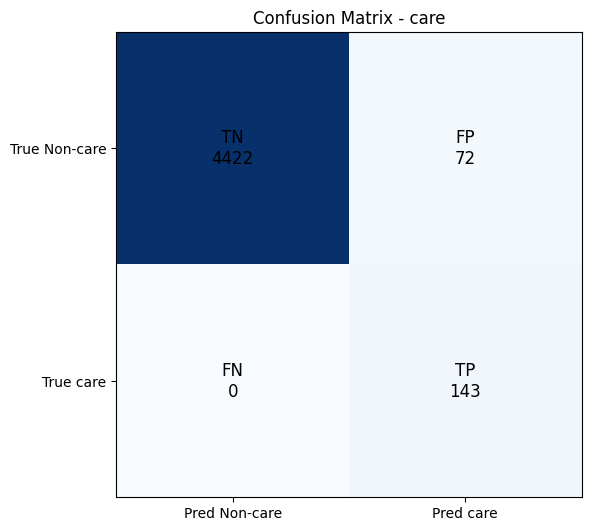

best_F1 0.7988826815642458
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris_v2/care
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9501661129568106

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      1.00      1.00      4494
        care       0.91      1.00      0.95       143

    accuracy                           1.00      4637
   macro avg       0.95      1.00      0.97      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.35102559790529053
Validation loss: 0.32446601154475374


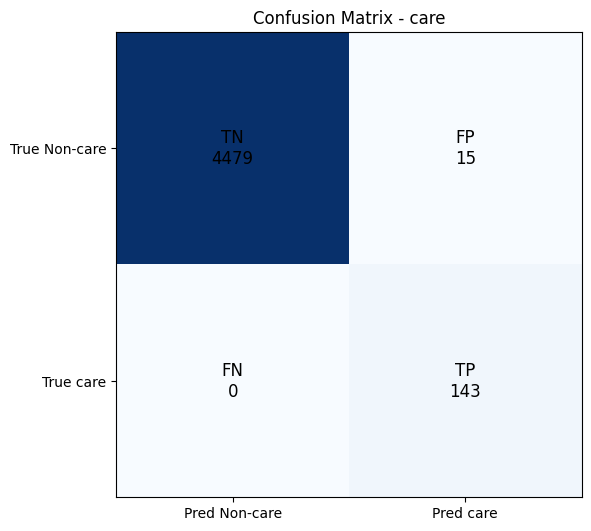

best_F1 0.9501661129568106
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris_v2/care
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9377049180327869

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      1.00      1.00      4494
        care       0.88      1.00      0.94       143

    accuracy                           1.00      4637
   macro avg       0.94      1.00      0.97      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33356778860605996
Validation loss: 0.32212929735923634


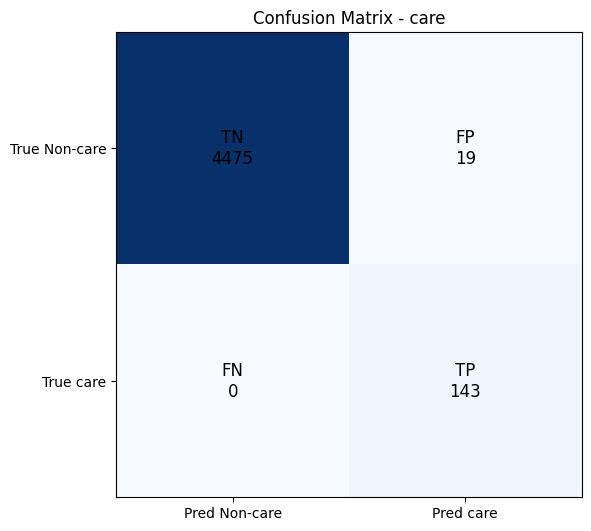

Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9727891156462585

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      1.00      1.00      4494
        care       0.95      1.00      0.97       143

    accuracy                           1.00      4637
   macro avg       0.97      1.00      0.99      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3263984860531215
Validation loss: 0.3185673471154838


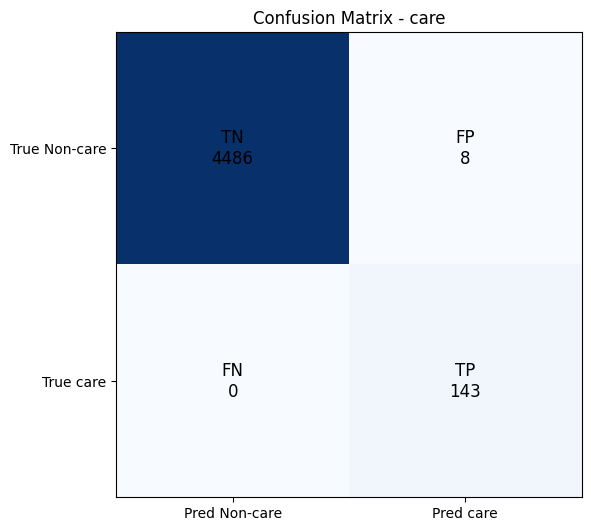

best_F1 0.9727891156462585
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris_v2/care
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9794520547945206

Classification Report:
              precision    recall  f1-score   support

    Non-care       1.00      1.00      1.00      4494
        care       0.96      1.00      0.98       143

    accuracy                           1.00      4637
   macro avg       0.98      1.00      0.99      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3225233593120657
Validation loss: 0.3166406991152928


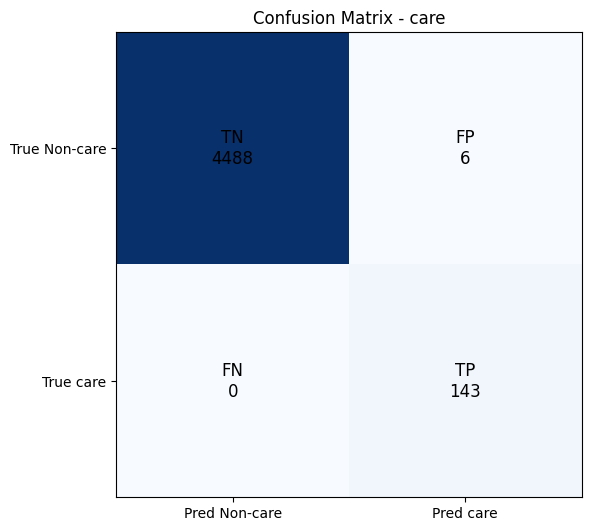

best_F1 0.9794520547945206
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'care' to: /content/drive/MyDrive/moralbert_inggris_v2/care
Models for predicting moral dimension with BERT Base
Label: harm
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for harm:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8789808917197452

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      0.98      0.99      4360
        harm       0.79      1.00      0.88       277

    accuracy                           0.98      4637
   macro avg       0.89      0.99      0.94      4637
weighted avg       0.99      0.98      0.98      4637


Train loss: 0.5330420273902088
Validation loss: 0.35933181324909474


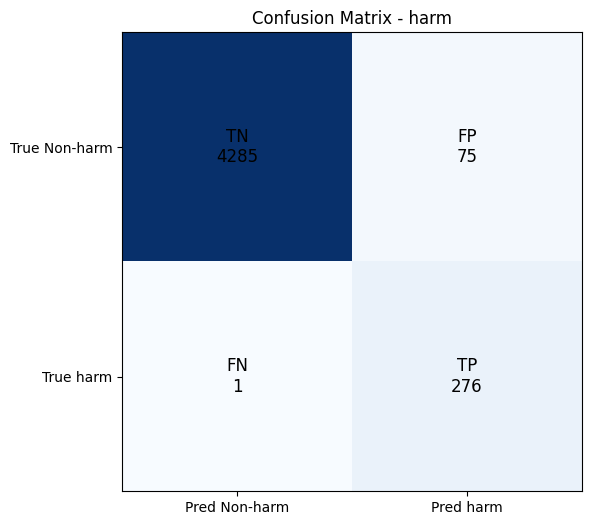

best_F1 0.8789808917197452
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris_v2/harm
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9551724137931035

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      0.99      1.00      4360
        harm       0.91      1.00      0.96       277

    accuracy                           0.99      4637
   macro avg       0.96      1.00      0.98      4637
weighted avg       0.99      0.99      0.99      4637


Train loss: 0.34807720572270195
Validation loss: 0.3291861629691617


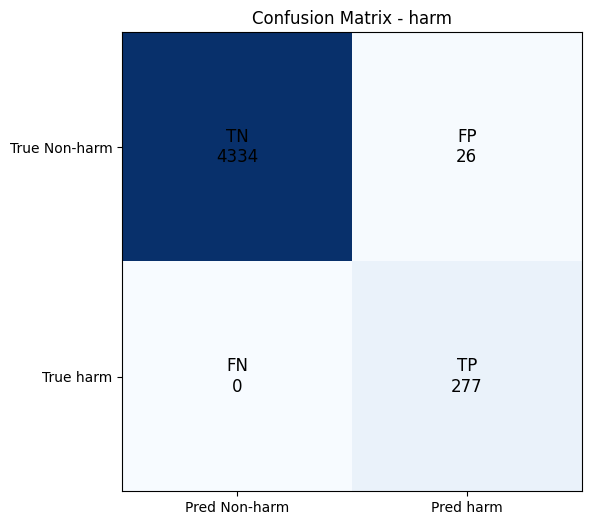

best_F1 0.9551724137931035
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris_v2/harm
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9668411867364747

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      1.00      1.00      4360
        harm       0.94      1.00      0.97       277

    accuracy                           1.00      4637
   macro avg       0.97      1.00      0.98      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33045403422980474
Validation loss: 0.32068195497167523


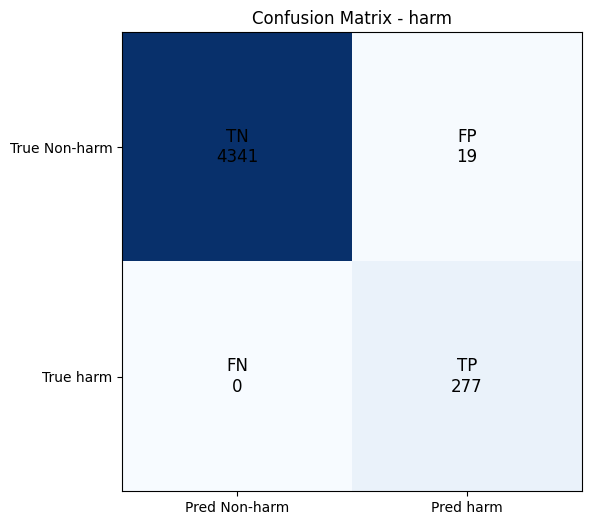

best_F1 0.9668411867364747
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris_v2/harm
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.992831541218638

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      1.00      1.00      4360
        harm       0.99      1.00      0.99       277

    accuracy                           1.00      4637
   macro avg       0.99      1.00      1.00      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.31981698916903856
Validation loss: 0.31451589465141294


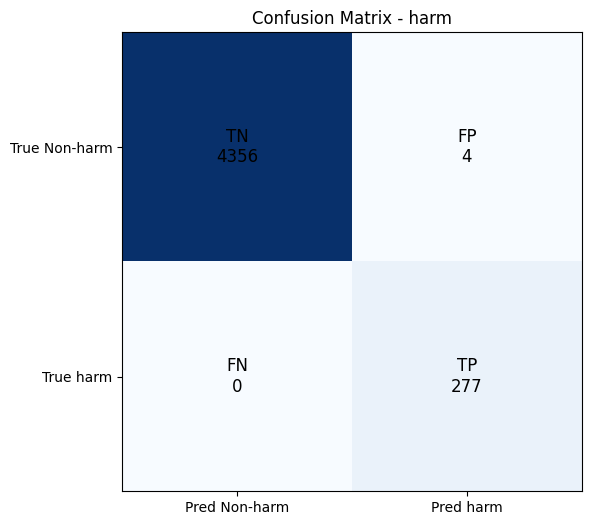

best_F1 0.992831541218638
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'harm' to: /content/drive/MyDrive/moralbert_inggris_v2/harm
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9875222816399287

Classification Report:
              precision    recall  f1-score   support

    Non-harm       1.00      1.00      1.00      4360
        harm       0.98      1.00      0.99       277

    accuracy                           1.00      4637
   macro avg       0.99      1.00      0.99      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3179876761960572
Validation loss: 0.31497829237888597


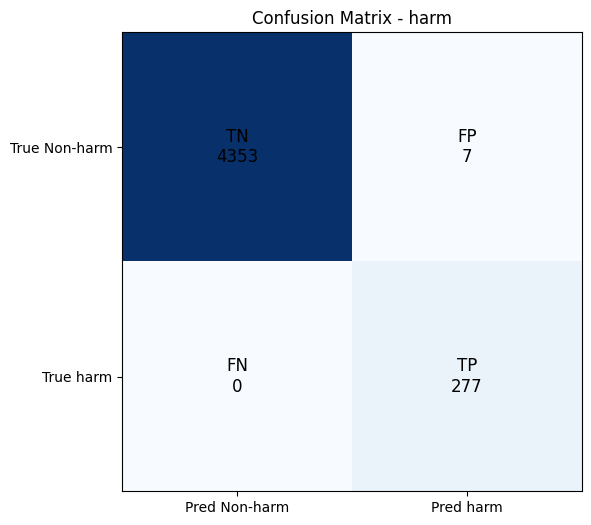

Models for predicting moral dimension with BERT Base
Label: fairness
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for fairness:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9347826086956522

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      0.99      1.00      4421
    fairness       0.88      1.00      0.93       216

    accuracy                           0.99      4637
   macro avg       0.94      0.99      0.97      4637
weighted avg       0.99      0.99      0.99      4637


Train loss: 0.5922204141729864
Validation loss: 0.3351321052888344


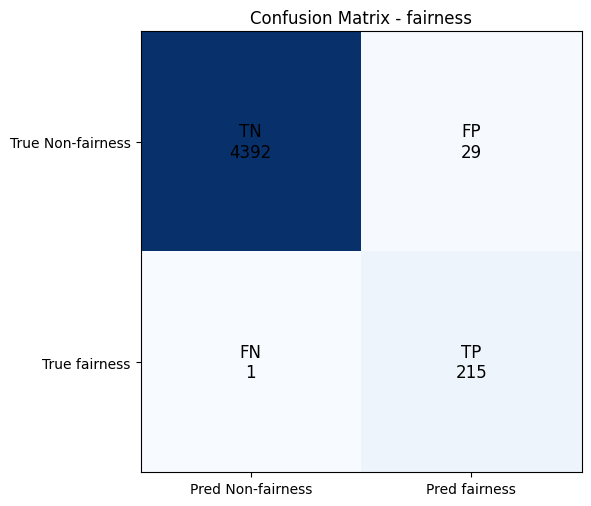

best_F1 0.9347826086956522
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris_v2/fairness
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9642857142857143

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      4421
    fairness       0.93      1.00      0.96       216

    accuracy                           1.00      4637
   macro avg       0.97      1.00      0.98      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.34273604103203476
Validation loss: 0.3249031835588916


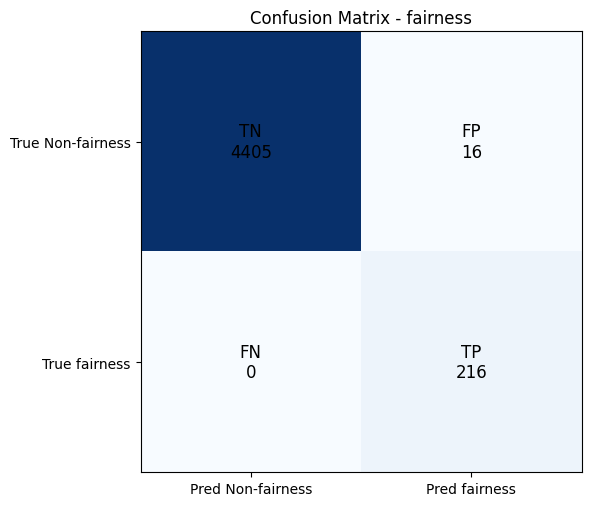

best_F1 0.9642857142857143
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris_v2/fairness
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9976905311778291

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      4421
    fairness       1.00      1.00      1.00       216

    accuracy                           1.00      4637
   macro avg       1.00      1.00      1.00      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3244558455358291
Validation loss: 0.3158915347066419


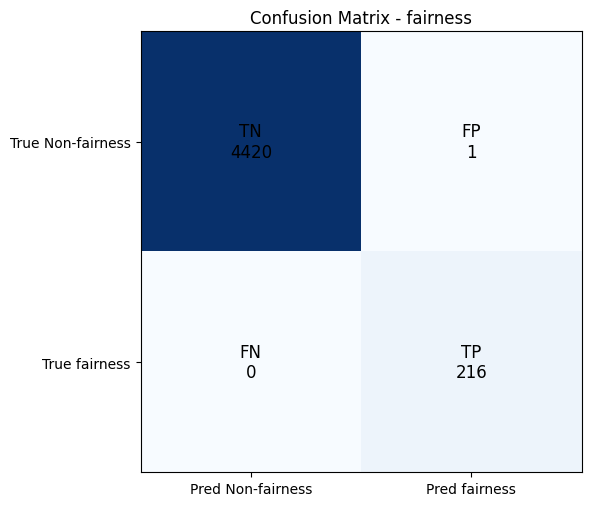

best_F1 0.9976905311778291
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'fairness' to: /content/drive/MyDrive/moralbert_inggris_v2/fairness
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9976905311778291

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      4421
    fairness       1.00      1.00      1.00       216

    accuracy                           1.00      4637
   macro avg       1.00      1.00      1.00      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32021435576266255
Validation loss: 0.31459961153309923


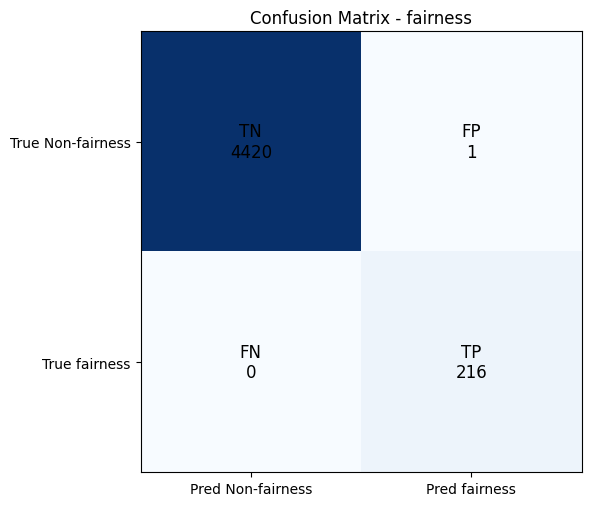

Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9930394431554525

Classification Report:
              precision    recall  f1-score   support

Non-fairness       1.00      1.00      1.00      4421
    fairness       1.00      0.99      0.99       216

    accuracy                           1.00      4637
   macro avg       1.00      1.00      1.00      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3188831477072732
Validation loss: 0.31497449258278154


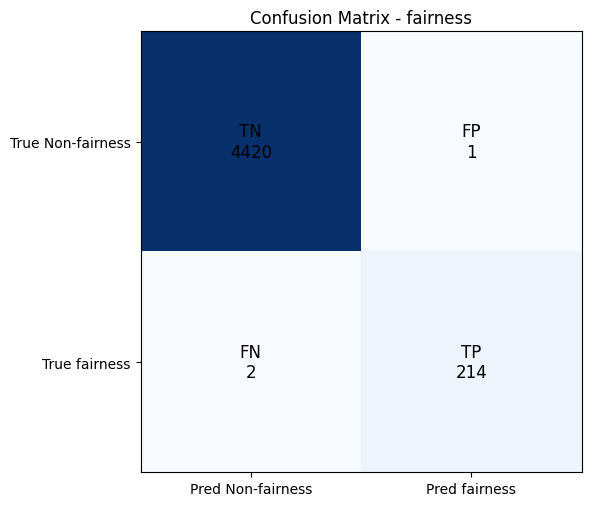

Models for predicting moral dimension with BERT Base
Label: cheating
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for cheating:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8173913043478261

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      4585
    cheating       0.75      0.90      0.82        52

    accuracy                           1.00      4637
   macro avg       0.87      0.95      0.91      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.581485011017528
Validation loss: 0.4021106328429847


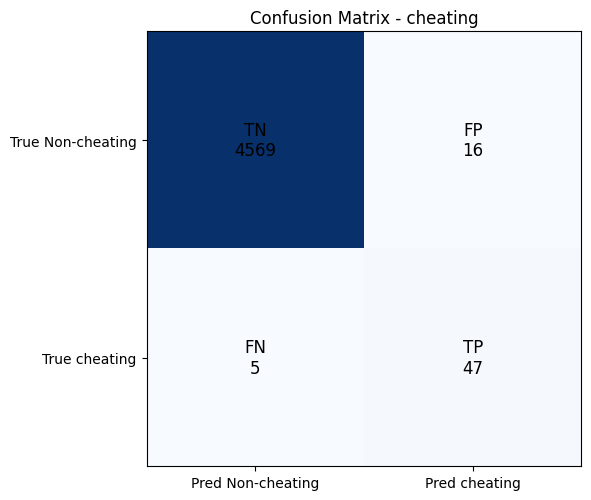

best_F1 0.8173913043478261
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'cheating' to: /content/drive/MyDrive/moralbert_inggris_v2/cheating
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8867924528301887

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      4585
    cheating       0.87      0.90      0.89        52

    accuracy                           1.00      4637
   macro avg       0.93      0.95      0.94      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33761482320982833
Validation loss: 0.4026814341545105


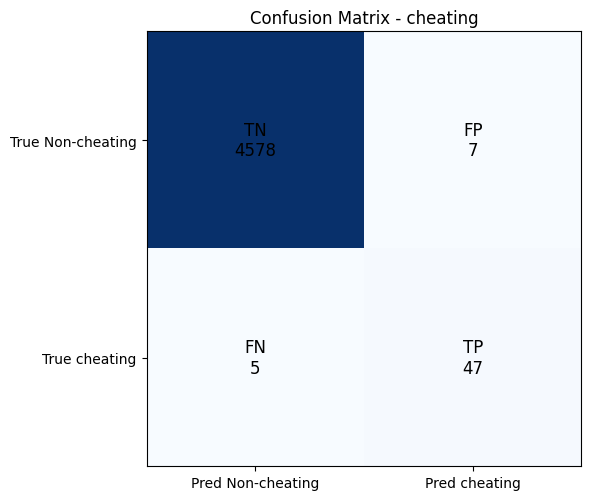

best_F1 0.8867924528301887
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'cheating' to: /content/drive/MyDrive/moralbert_inggris_v2/cheating
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8727272727272727

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      4585
    cheating       0.83      0.92      0.87        52

    accuracy                           1.00      4637
   macro avg       0.91      0.96      0.94      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3320155266800831
Validation loss: 0.3882625997066498


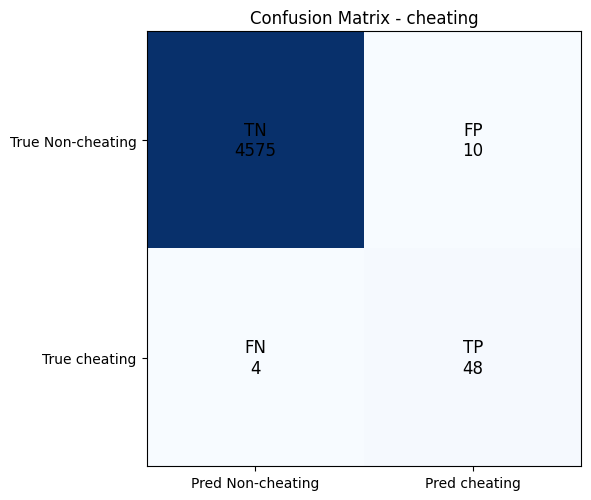

Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8952380952380953

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      4585
    cheating       0.89      0.90      0.90        52

    accuracy                           1.00      4637
   macro avg       0.94      0.95      0.95      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32092474254554715
Validation loss: 0.4059096631304971


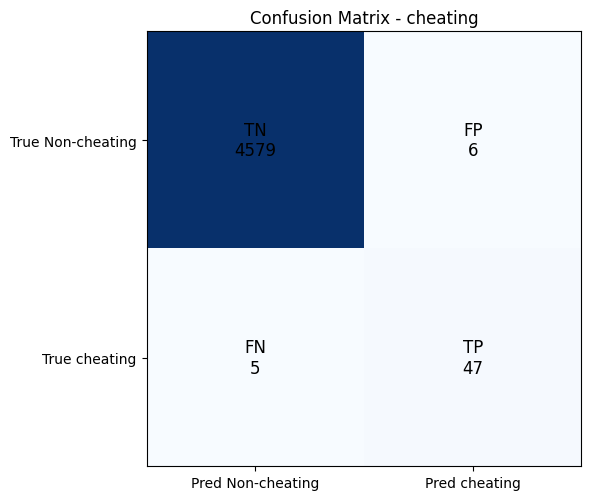

best_F1 0.8952380952380953
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'cheating' to: /content/drive/MyDrive/moralbert_inggris_v2/cheating
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8952380952380953

Classification Report:
              precision    recall  f1-score   support

Non-cheating       1.00      1.00      1.00      4585
    cheating       0.89      0.90      0.90        52

    accuracy                           1.00      4637
   macro avg       0.94      0.95      0.95      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3199571800129167
Validation loss: 0.40685007489960767


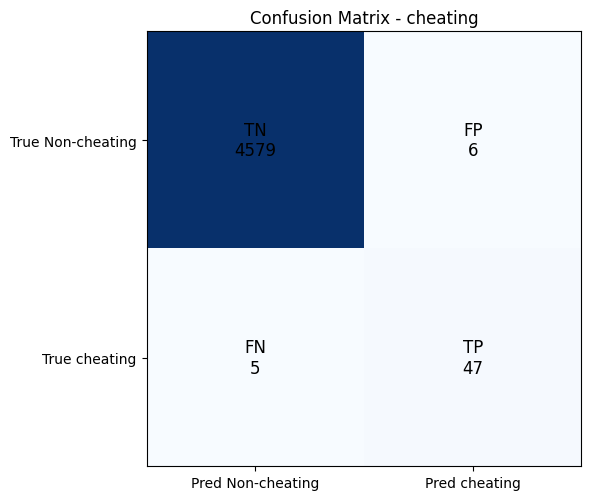

Models for predicting moral dimension with BERT Base
Label: loyalty
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for loyalty:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8378378378378378

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      4602
     loyalty       0.79      0.89      0.84        35

    accuracy                           1.00      4637
   macro avg       0.90      0.94      0.92      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.6159939674210959
Validation loss: 0.38663211166858674


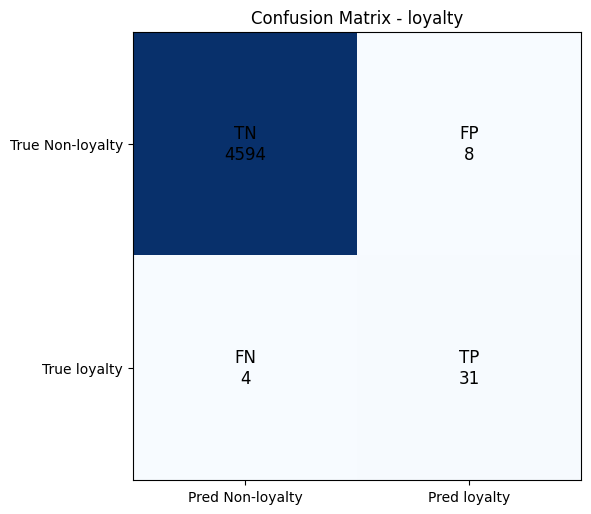

best_F1 0.8378378378378378
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris_v2/loyalty
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9066666666666666

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      4602
     loyalty       0.85      0.97      0.91        35

    accuracy                           1.00      4637
   macro avg       0.92      0.99      0.95      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3584431358966334
Validation loss: 0.335568014506636


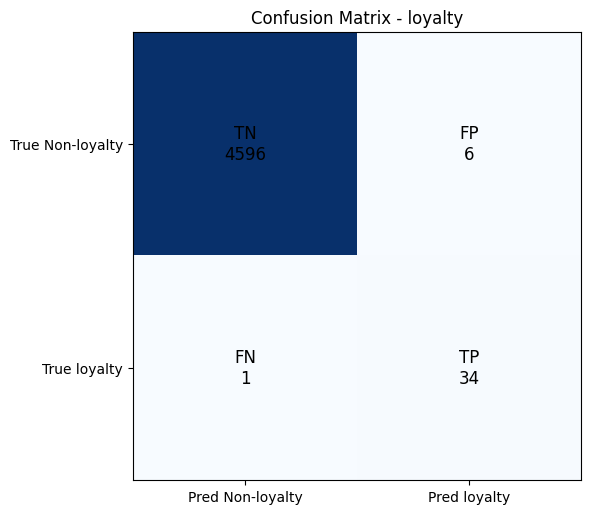

best_F1 0.9066666666666666
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris_v2/loyalty
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8974358974358975

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      4602
     loyalty       0.81      1.00      0.90        35

    accuracy                           1.00      4637
   macro avg       0.91      1.00      0.95      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3325273842647158
Validation loss: 0.3187927292338733


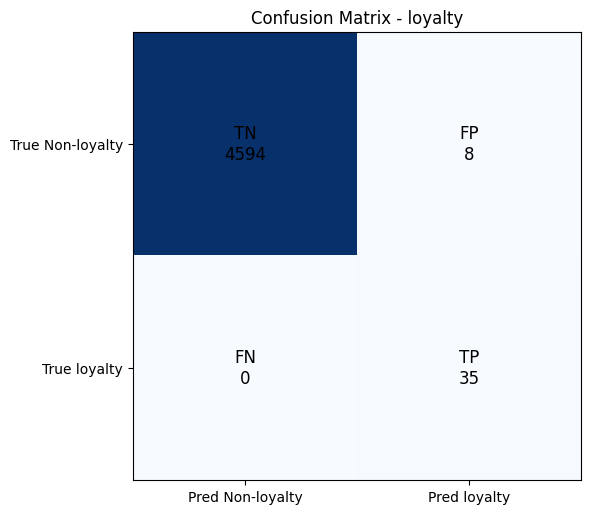

Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9459459459459459

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      4602
     loyalty       0.90      1.00      0.95        35

    accuracy                           1.00      4637
   macro avg       0.95      1.00      0.97      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3227593968654501
Validation loss: 0.3162227782709845


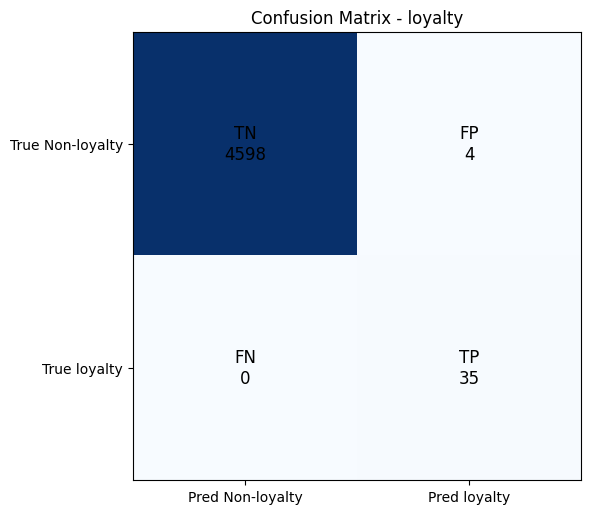

best_F1 0.9459459459459459
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris_v2/loyalty
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.958904109589041

Classification Report:
              precision    recall  f1-score   support

 Non-loyalty       1.00      1.00      1.00      4602
     loyalty       0.92      1.00      0.96        35

    accuracy                           1.00      4637
   macro avg       0.96      1.00      0.98      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3202812970969184
Validation loss: 0.3147515960808458


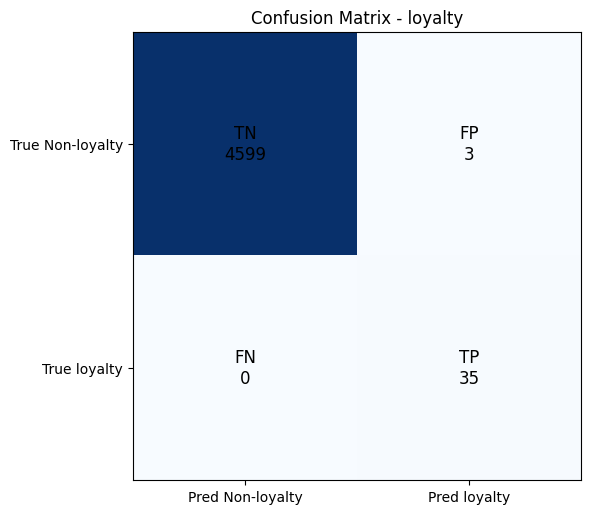

best_F1 0.958904109589041
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'loyalty' to: /content/drive/MyDrive/moralbert_inggris_v2/loyalty
Models for predicting moral dimension with BERT Base
Label: betrayal
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for betrayal:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      4619
    betrayal       0.00      0.00      0.00        18

    accuracy                           1.00      4637
   macro avg       0.50      0.50      0.50      4637
weighted avg       0.99      1.00      0.99      4637


Train loss: 0.5324124629641401
Validation loss: 0.48920404119738214


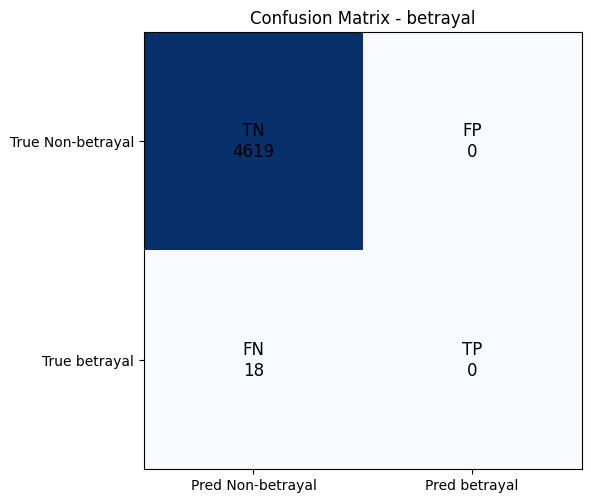

best_F1 0.0
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris_v2/betrayal
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.6296296296296297

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      4619
    betrayal       0.47      0.94      0.63        18

    accuracy                           1.00      4637
   macro avg       0.74      0.97      0.81      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.4150592986622761
Validation loss: 0.3479567007771854


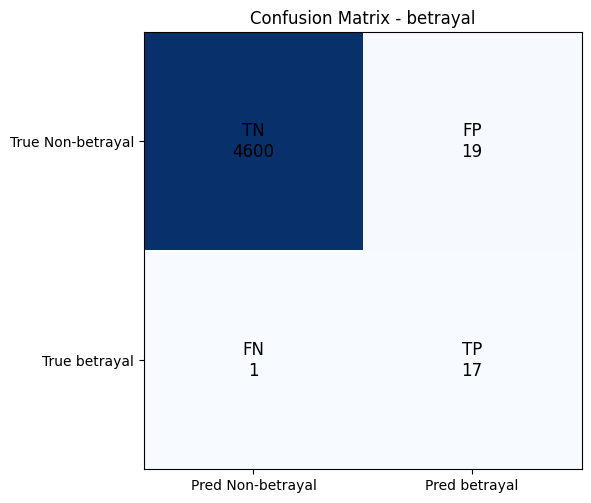

best_F1 0.6296296296296297
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris_v2/betrayal
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      4619
    betrayal       0.80      0.89      0.84        18

    accuracy                           1.00      4637
   macro avg       0.90      0.94      0.92      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33264209160517
Validation loss: 0.3523541722832055


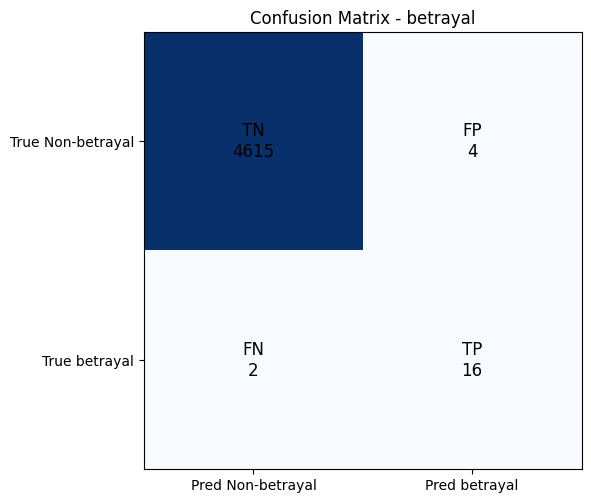

best_F1 0.8421052631578947
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris_v2/betrayal
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9142857142857143

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      4619
    betrayal       0.94      0.89      0.91        18

    accuracy                           1.00      4637
   macro avg       0.97      0.94      0.96      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3213309039843493
Validation loss: 0.3584372511197781


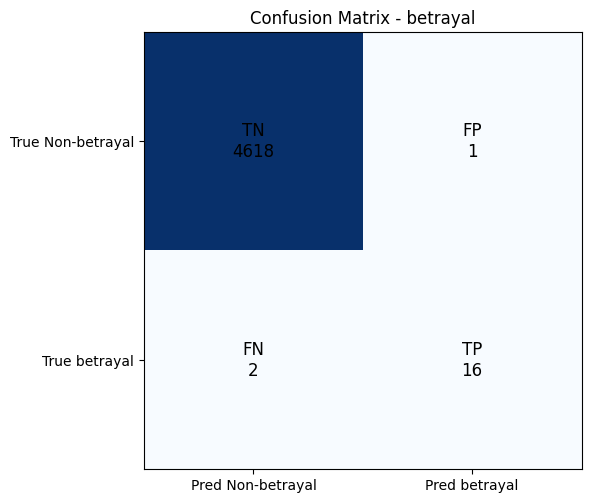

best_F1 0.9142857142857143
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'betrayal' to: /content/drive/MyDrive/moralbert_inggris_v2/betrayal
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9142857142857143

Classification Report:
              precision    recall  f1-score   support

Non-betrayal       1.00      1.00      1.00      4619
    betrayal       0.94      0.89      0.91        18

    accuracy                           1.00      4637
   macro avg       0.97      0.94      0.96      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32030186540093913
Validation loss: 0.34817985512059313


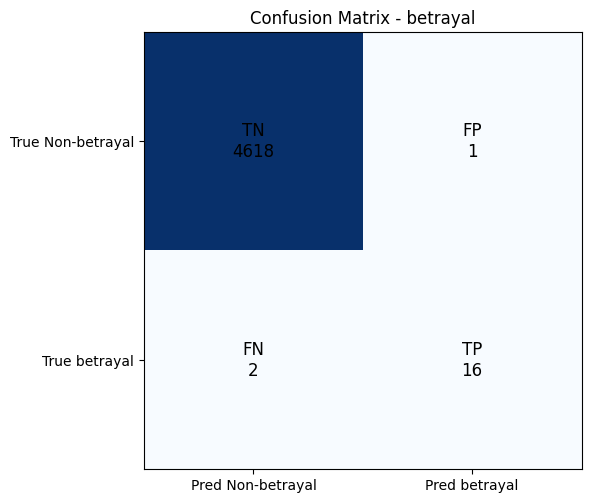

Models for predicting moral dimension with BERT Base
Label: authority
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for authority:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9051987767584098

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      0.99      1.00      4486
    authority       0.84      0.98      0.91       151

     accuracy                           0.99      4637
    macro avg       0.92      0.99      0.95      4637
 weighted avg       0.99      0.99      0.99      4637


Train loss: 0.5897098590587747
Validation loss: 0.35807670724803004


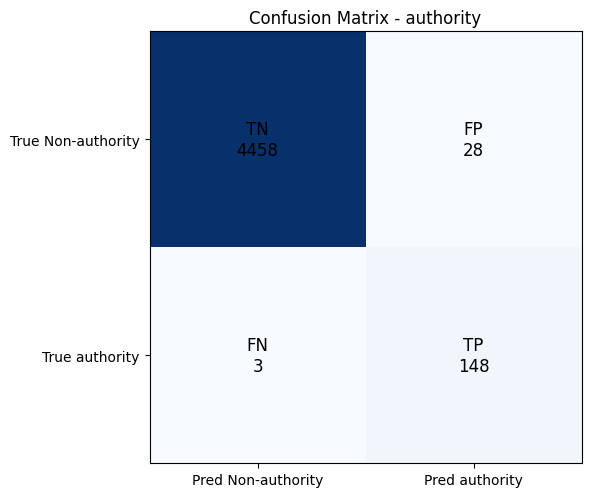

best_F1 0.9051987767584098
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'authority' to: /content/drive/MyDrive/moralbert_inggris_v2/authority
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9706840390879479

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      4486
    authority       0.96      0.99      0.97       151

     accuracy                           1.00      4637
    macro avg       0.98      0.99      0.98      4637
 weighted avg       1.00      1.00      1.00      4637


Train loss: 0.35323951354828376
Validation loss: 0.33836504364835807


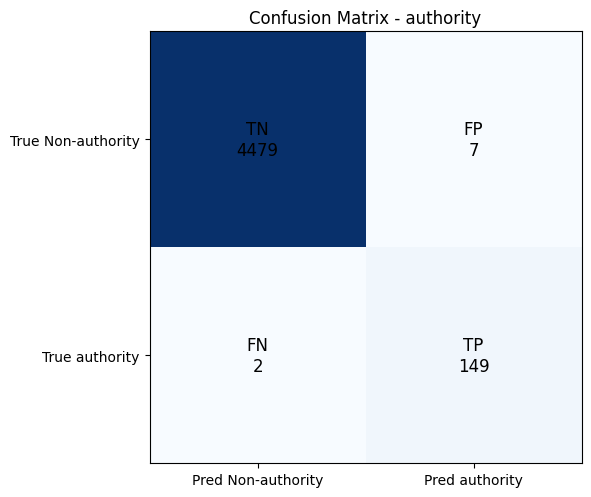

best_F1 0.9706840390879479
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'authority' to: /content/drive/MyDrive/moralbert_inggris_v2/authority
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9706840390879479

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      4486
    authority       0.96      0.99      0.97       151

     accuracy                           1.00      4637
    macro avg       0.98      0.99      0.98      4637
 weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33495500984376875
Validation loss: 0.3326490073368467


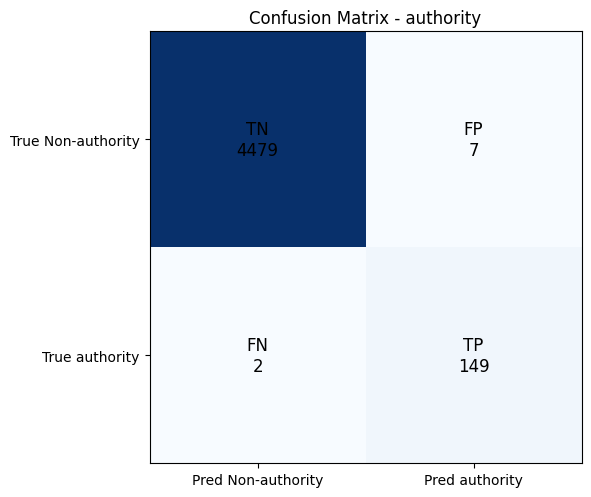

Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9801324503311258

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      4486
    authority       0.98      0.98      0.98       151

     accuracy                           1.00      4637
    macro avg       0.99      0.99      0.99      4637
 weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32465092853225513
Validation loss: 0.3359070420265198


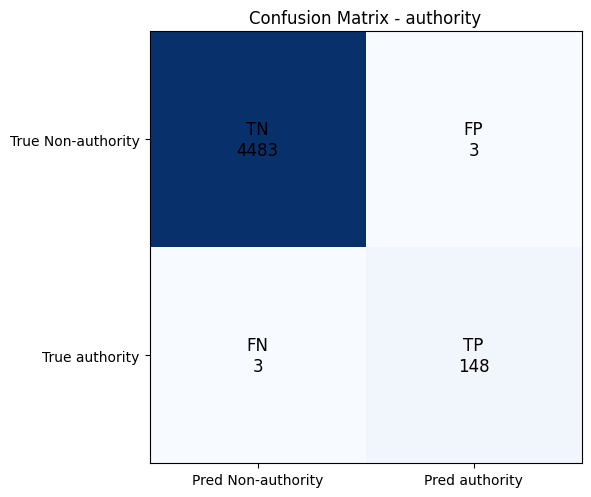

best_F1 0.9801324503311258
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'authority' to: /content/drive/MyDrive/moralbert_inggris_v2/authority
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9801324503311258

Classification Report:
               precision    recall  f1-score   support

Non-authority       1.00      1.00      1.00      4486
    authority       0.98      0.98      0.98       151

     accuracy                           1.00      4637
    macro avg       0.99      0.99      0.99      4637
 weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32103519704321337
Validation loss: 0.3368692707398842


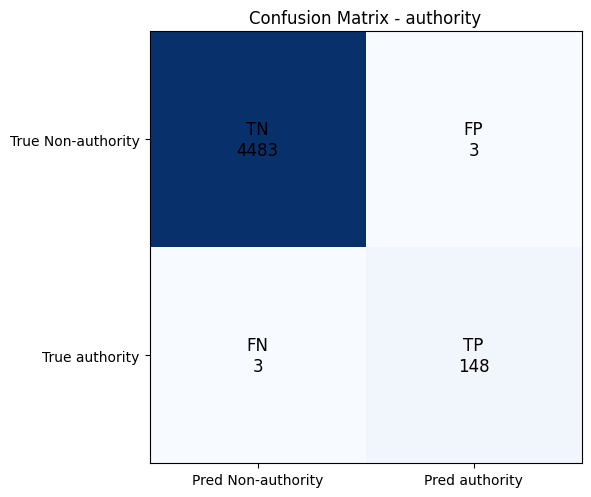

Models for predicting moral dimension with BERT Base
Label: subversion
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for subversion:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      4631
    subversion       0.00      0.00      0.00         6

      accuracy                           1.00      4637
     macro avg       0.50      0.50      0.50      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.43182796702302734
Validation loss: 0.4171143818518211


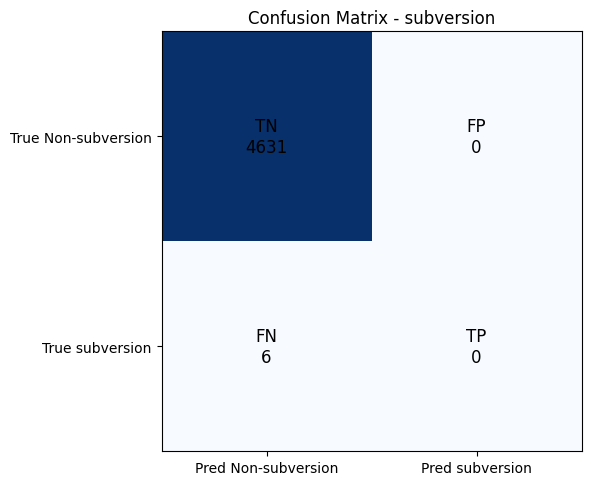

best_F1 0.0
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'subversion' to: /content/drive/MyDrive/moralbert_inggris_v2/subversion
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      4631
    subversion       0.00      0.00      0.00         6

      accuracy                           1.00      4637
     macro avg       0.50      0.50      0.50      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.39526296540580946
Validation loss: 0.4315653237803229


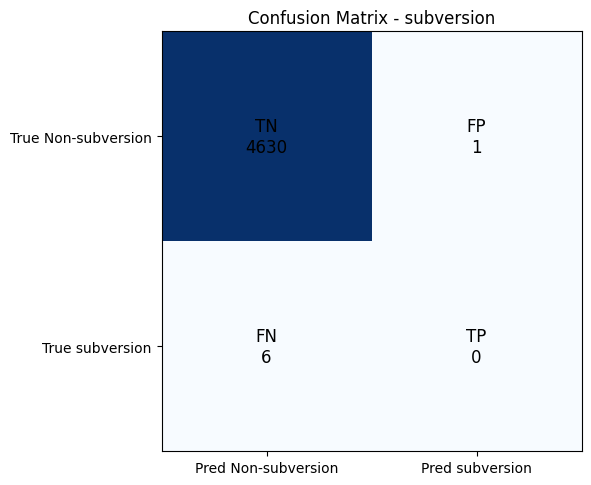

Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      4631
    subversion       0.00      0.00      0.00         6

      accuracy                           1.00      4637
     macro avg       0.50      0.50      0.50      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3389782474472605
Validation loss: 0.41632967755712313


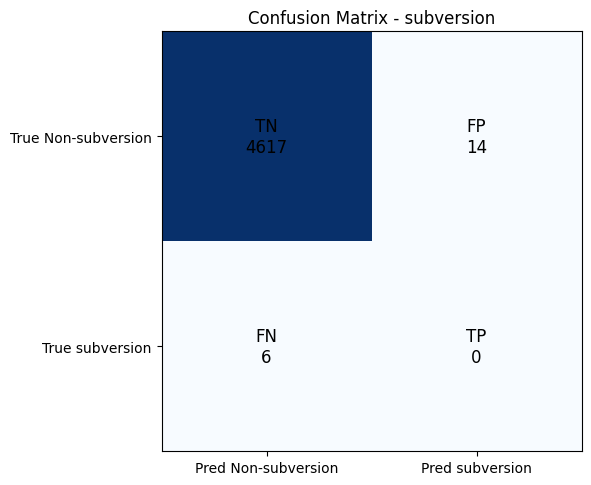

Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      4631
    subversion       0.00      0.00      0.00         6

      accuracy                           1.00      4637
     macro avg       0.50      0.50      0.50      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3213836314863172
Validation loss: 0.4679447824585027


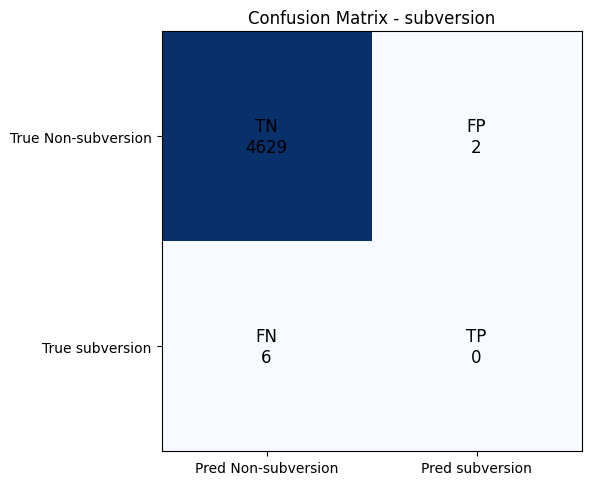

Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.0

Classification Report:
                precision    recall  f1-score   support

Non-subversion       1.00      1.00      1.00      4631
    subversion       0.00      0.00      0.00         6

      accuracy                           1.00      4637
     macro avg       0.50      0.50      0.50      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3191453563755956
Validation loss: 0.4734536373409732


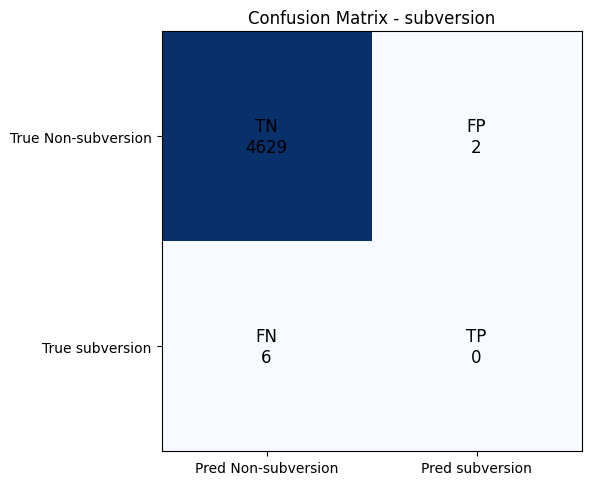

Models for predicting moral dimension with BERT Base
Label: purity
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for purity:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8467741935483871

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      0.99      1.00      4531
      purity       0.74      0.99      0.85       106

    accuracy                           0.99      4637
   macro avg       0.87      0.99      0.92      4637
weighted avg       0.99      0.99      0.99      4637


Train loss: 0.5875239228123221
Validation loss: 0.3537405898858761


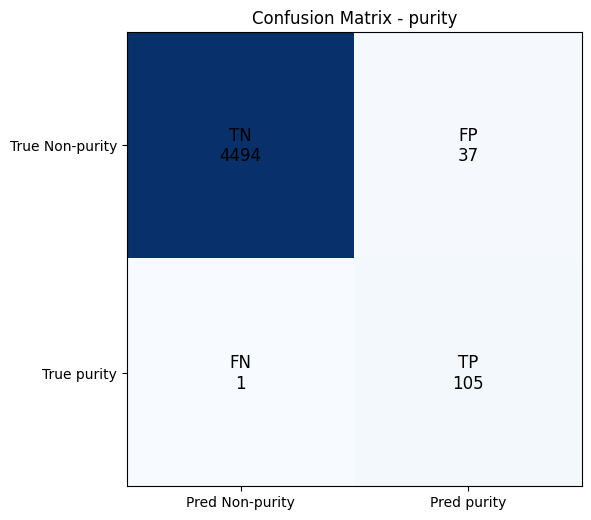

best_F1 0.8467741935483871
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris_v2/purity
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.963302752293578

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      4531
      purity       0.94      0.99      0.96       106

    accuracy                           1.00      4637
   macro avg       0.97      0.99      0.98      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3476976029574871
Validation loss: 0.32295804609512463


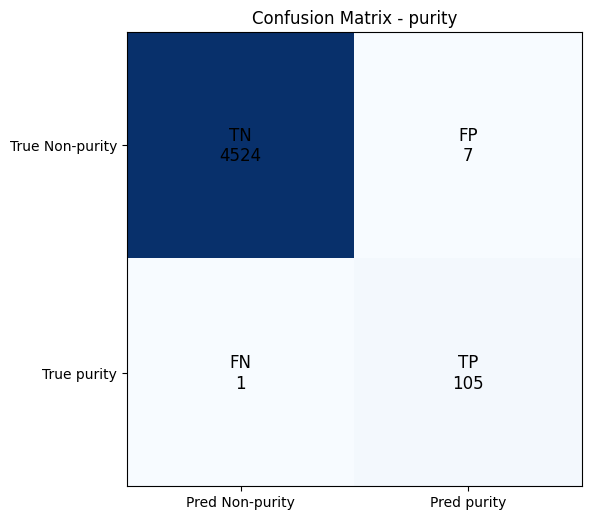

best_F1 0.963302752293578
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris_v2/purity
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.967741935483871

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      4531
      purity       0.95      0.99      0.97       106

    accuracy                           1.00      4637
   macro avg       0.97      0.99      0.98      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3268619006820794
Validation loss: 0.32240275185683676


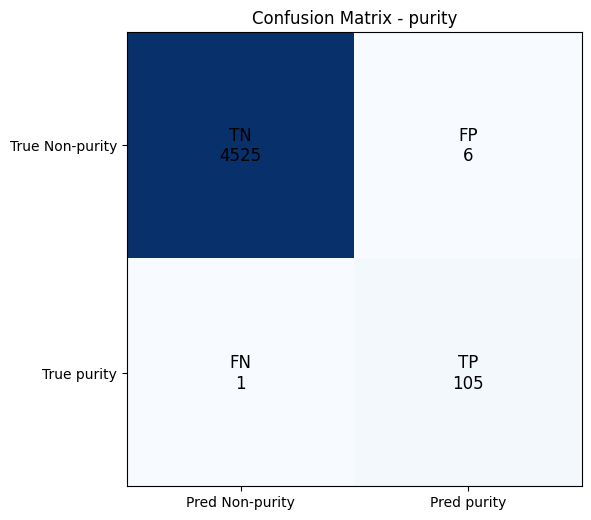

best_F1 0.967741935483871
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris_v2/purity
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9722222222222222

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      4531
      purity       0.95      0.99      0.97       106

    accuracy                           1.00      4637
   macro avg       0.98      0.99      0.99      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3212070392894334
Validation loss: 0.3270370458734447


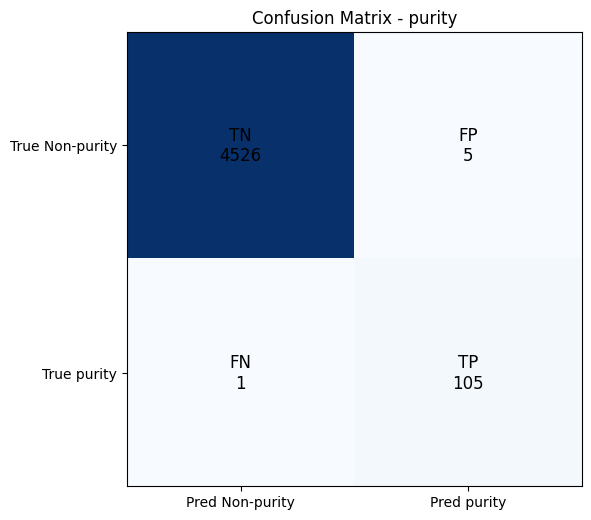

best_F1 0.9722222222222222
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris_v2/purity
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9724770642201835

Classification Report:
              precision    recall  f1-score   support

  Non-purity       1.00      1.00      1.00      4531
      purity       0.95      1.00      0.97       106

    accuracy                           1.00      4637
   macro avg       0.97      1.00      0.99      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.31988228225502474
Validation loss: 0.3165415364092794


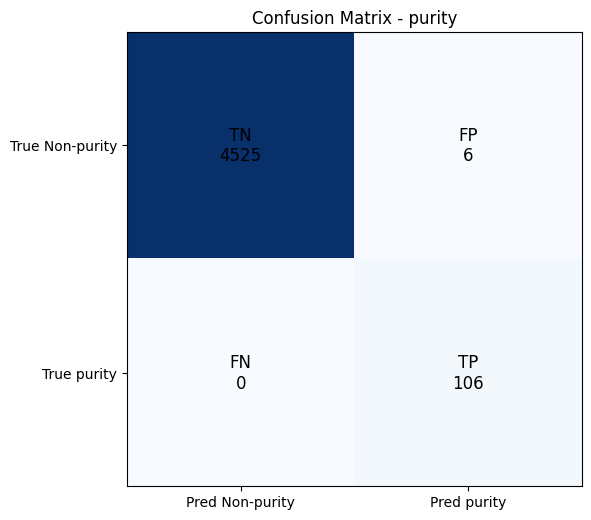

best_F1 0.9724770642201835
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'purity' to: /content/drive/MyDrive/moralbert_inggris_v2/purity
Models for predicting moral dimension with BERT Base
Label: degradation
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for degradation:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.90625

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      4607
    degradation       0.85      0.97      0.91        30

       accuracy                           1.00      4637
      macro avg       0.93      0.98      0.95      4637
   weighted avg       1.00      1.00      1.00      4637


Train loss: 0.5258757678599193
Validation loss: 0.34431486325017335


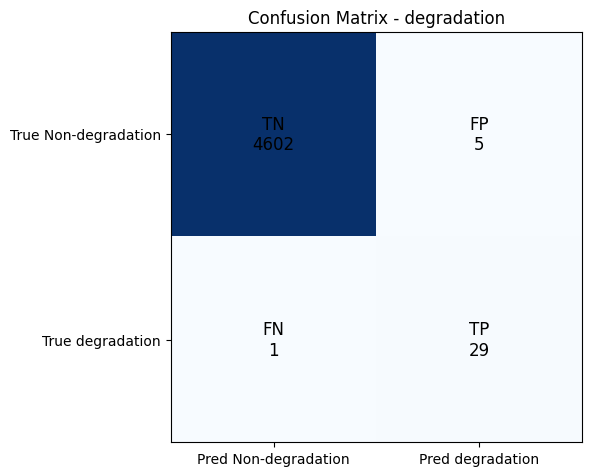

best_F1 0.90625
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'degradation' to: /content/drive/MyDrive/moralbert_inggris_v2/degradation
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8823529411764706

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      4607
    degradation       0.79      1.00      0.88        30

       accuracy                           1.00      4637
      macro avg       0.89      1.00      0.94      4637
   weighted avg       1.00      1.00      1.00      4637


Train loss: 0.36225666141715546
Validation loss: 0.32182829544462005


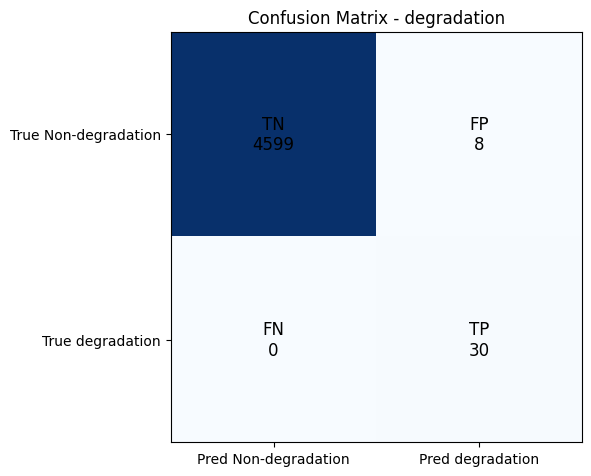

Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9523809523809523

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      4607
    degradation       0.91      1.00      0.95        30

       accuracy                           1.00      4637
      macro avg       0.95      1.00      0.98      4637
   weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33117411637614513
Validation loss: 0.3158665460759196


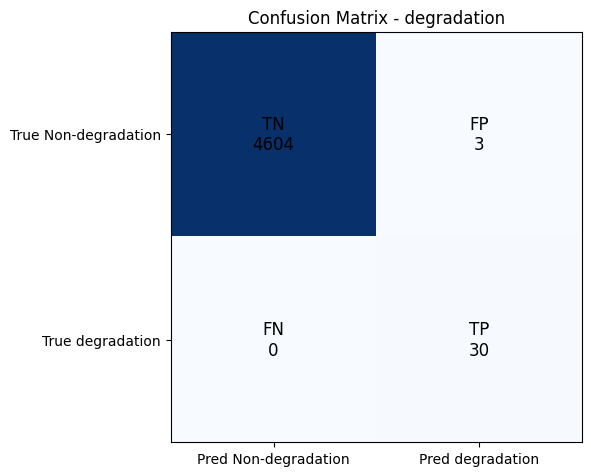

best_F1 0.9523809523809523
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'degradation' to: /content/drive/MyDrive/moralbert_inggris_v2/degradation
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.967741935483871

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      4607
    degradation       0.94      1.00      0.97        30

       accuracy                           1.00      4637
      macro avg       0.97      1.00      0.98      4637
   weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3215159950071368
Validation loss: 0.3134394837864514


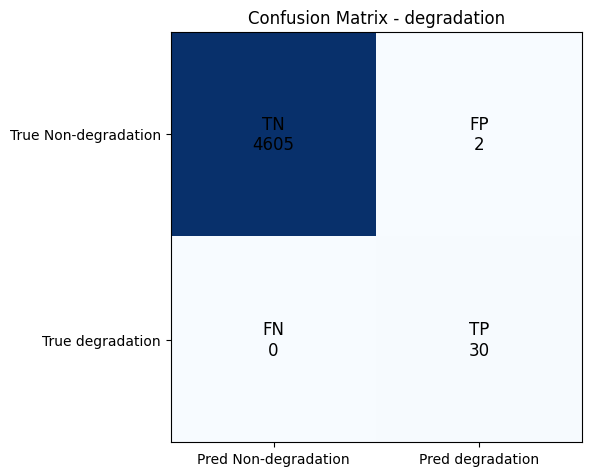

best_F1 0.967741935483871
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'degradation' to: /content/drive/MyDrive/moralbert_inggris_v2/degradation
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9836065573770492

Classification Report:
                 precision    recall  f1-score   support

Non-degradation       1.00      1.00      1.00      4607
    degradation       0.97      1.00      0.98        30

       accuracy                           1.00      4637
      macro avg       0.98      1.00      0.99      4637
   weighted avg       1.00      1.00      1.00      4637


Train loss: 0.31988859518334783
Validation loss: 0.31266382336616516


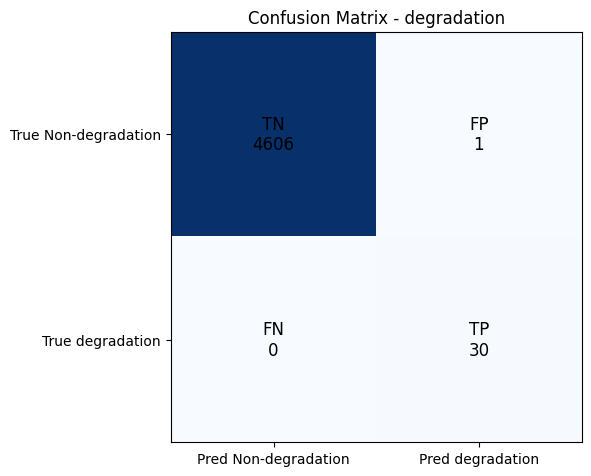

best_F1 0.9836065573770492
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'degradation' to: /content/drive/MyDrive/moralbert_inggris_v2/degradation
Models for predicting moral dimension with BERT Base
Label: liberty
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Epochs for liberty:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8761904761904762

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      4591
     liberty       0.78      1.00      0.88        46

    accuracy                           1.00      4637
   macro avg       0.89      1.00      0.94      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.5634382716283716
Validation loss: 0.3296104983009141


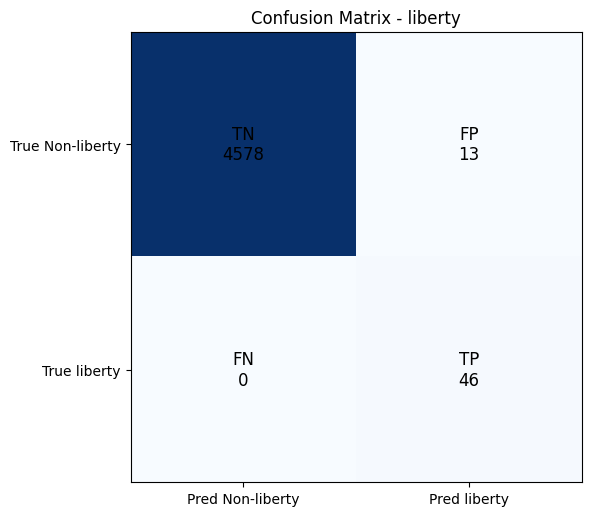

best_F1 0.8761904761904762
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'liberty' to: /content/drive/MyDrive/moralbert_inggris_v2/liberty
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9484536082474226

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      4591
     liberty       0.90      1.00      0.95        46

    accuracy                           1.00      4637
   macro avg       0.95      1.00      0.97      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3554780747613003
Validation loss: 0.31952403280241737


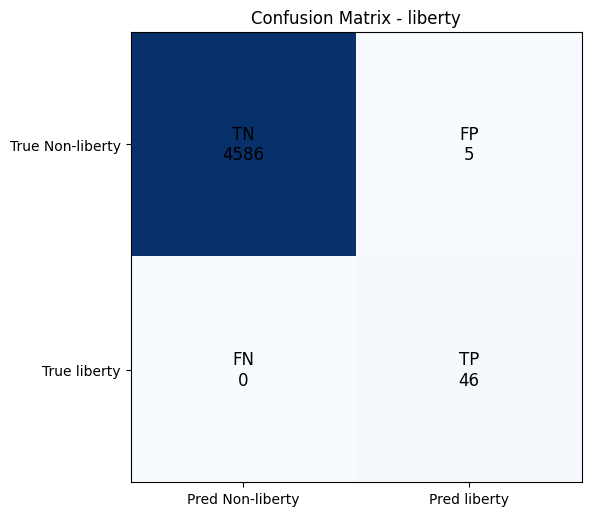

best_F1 0.9484536082474226
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'liberty' to: /content/drive/MyDrive/moralbert_inggris_v2/liberty
Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 1.0

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      4591
     liberty       1.00      1.00      1.00        46

    accuracy                           1.00      4637
   macro avg       1.00      1.00      1.00      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33320225171487905
Validation loss: 0.3150881507273378


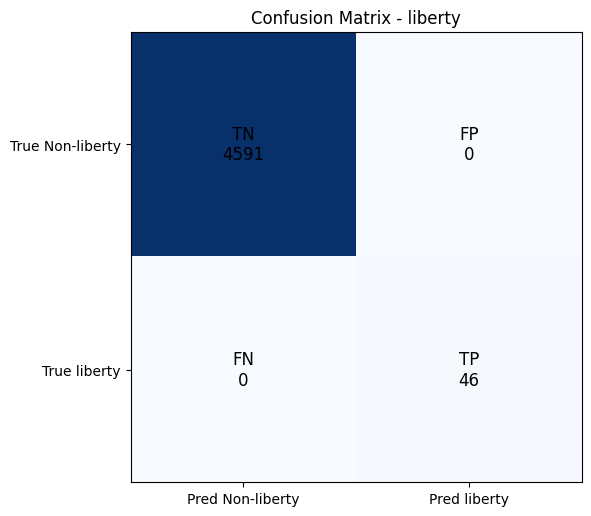

best_F1 1.0
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'liberty' to: /content/drive/MyDrive/moralbert_inggris_v2/liberty
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9292929292929293

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      4591
     liberty       0.87      1.00      0.93        46

    accuracy                           1.00      4637
   macro avg       0.93      1.00      0.96      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32266058341182513
Validation loss: 0.3171063468374055


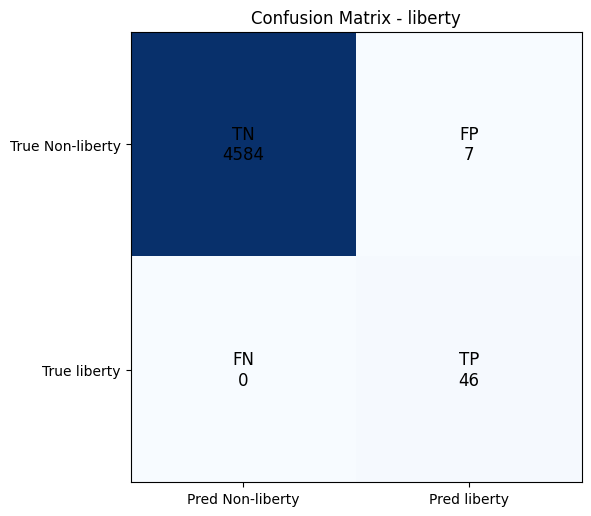

Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.989247311827957

Classification Report:
              precision    recall  f1-score   support

 Non-liberty       1.00      1.00      1.00      4591
     liberty       0.98      1.00      0.99        46

    accuracy                           1.00      4637
   macro avg       0.99      1.00      0.99      4637
weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3201435388419135
Validation loss: 0.31320668448661937


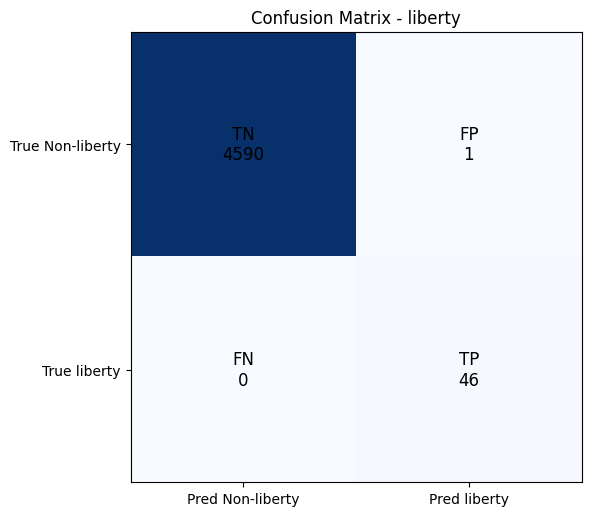

Models for predicting moral dimension with BERT Base
Label: oppression
Parameters: reconstruction_weight = 0.1; identity_weight = 0.01


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs for oppression:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1


/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8380952380952381

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      4591
    oppression       0.75      0.96      0.84        46

      accuracy                           1.00      4637
     macro avg       0.87      0.98      0.92      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.5718812466181558
Validation loss: 0.34517462489933803


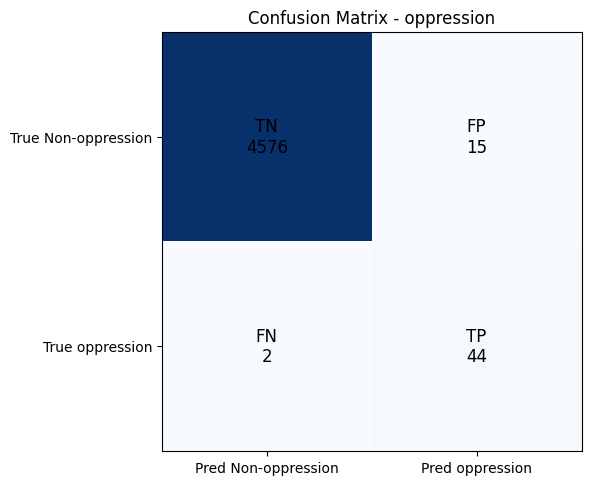

best_F1 0.8380952380952381
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris_v2/oppression
Epoch: 2


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.5443786982248521

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      0.98      0.99      4591
    oppression       0.37      1.00      0.54        46

      accuracy                           0.98      4637
     macro avg       0.69      0.99      0.77      4637
  weighted avg       0.99      0.98      0.99      4637


Train loss: 0.3621341856903043
Validation loss: 0.36177128676710457


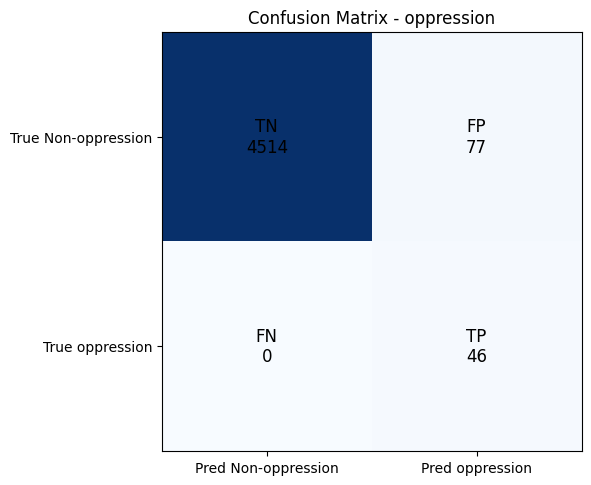

Epoch: 3


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.8932038834951457

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      4591
    oppression       0.81      1.00      0.89        46

      accuracy                           1.00      4637
     macro avg       0.90      1.00      0.95      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.33820874418677954
Validation loss: 0.32127301004426234


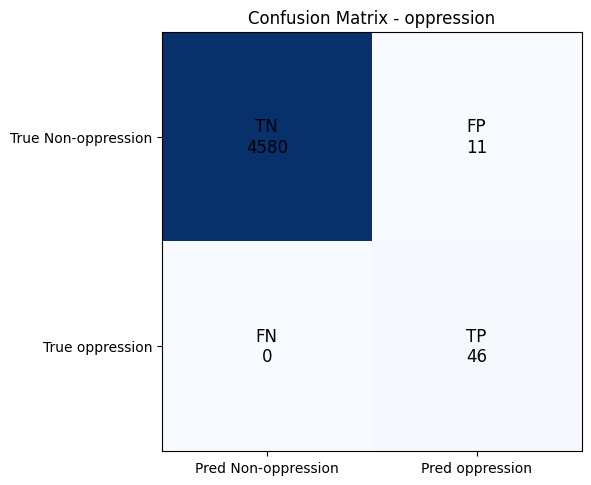

best_F1 0.8932038834951457
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris_v2/oppression
Epoch: 4


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9108910891089109

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      4591
    oppression       0.84      1.00      0.91        46

      accuracy                           1.00      4637
     macro avg       0.92      1.00      0.95      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.3263702234574433
Validation loss: 0.31784983914473963


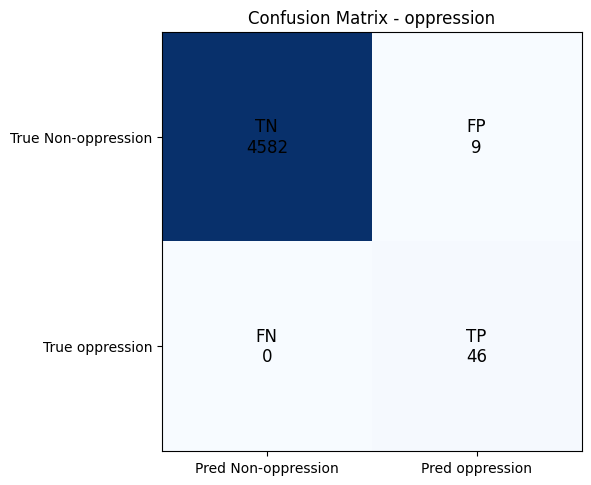

best_F1 0.9108910891089109
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris_v2/oppression
Epoch: 5


/tmp/ipykernel_933/1058689007.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_933/1058689007.py:138: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluation
F1 score: 0.9583333333333334

Classification Report:
                precision    recall  f1-score   support

Non-oppression       1.00      1.00      1.00      4591
    oppression       0.92      1.00      0.96        46

      accuracy                           1.00      4637
     macro avg       0.96      1.00      0.98      4637
  weighted avg       1.00      1.00      1.00      4637


Train loss: 0.32093345340469787
Validation loss: 0.3160271581904642


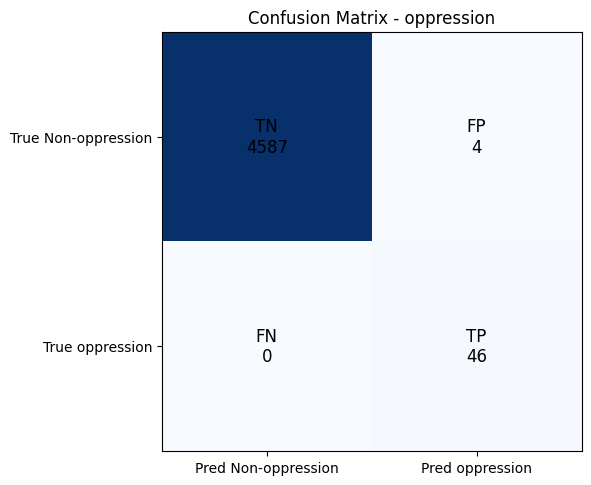

best_F1 0.9583333333333334
Saving best native Hugging Face model ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best native HF checkpoint for 'oppression' to: /content/drive/MyDrive/moralbert_inggris_v2/oppression


,label,best_f1,best_epoch,export_dir
0,care,0.979452,5,/content/drive/MyDrive/moralbert_inggris_v2/care
1,harm,0.992832,4,/content/drive/MyDrive/moralbert_inggris_v2/harm
2,fairness,0.997691,3,/content/drive/MyDrive/moralbert_inggris_v2/fa...
3,cheating,0.895238,4,/content/drive/MyDrive/moralbert_inggris_v2/ch...
4,loyalty,0.958904,5,/content/drive/MyDrive/moralbert_inggris_v2/lo...
5,betrayal,0.914286,4,/content/drive/MyDrive/moralbert_inggris_v2/be...
6,authority,0.980132,4,/content/drive/MyDrive/moralbert_inggris_v2/au...
7,subversion,0.000000,1,/content/drive/MyDrive/moralbert_inggris_v2/su...
8,purity,0.972477,5,/content/drive/MyDrive/moralbert_inggris_v2/pu...
9,degradation,0.983607,5,/content/drive/MyDrive/moralbert_inggris_v2/de...


In [17]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

possible_labels = [
    "care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"
]

bert_original_embeddings = None
training_summary = []

for lab_idx, lab in enumerate(possible_labels):

    best_f1 = -1
    best_epoch = -1

    num_labels = 2
    epochs = 5
    batch_size = 16

    rw = 0.1
    iw = 0.01

    print("Models for predicting moral dimension with BERT Base")
    print(f"Label: {lab}")
    print(f"Parameters: reconstruction_weight = {rw}; identity_weight = {iw}")

    temp_bert_model = AutoModel.from_pretrained(base_model).to(
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )

    if bert_original_embeddings is None:
        bert_original_embeddings = encode_corpus(
            train_input_ids,
            train_attention_masks,
            temp_bert_model
        )

    train_binary_labels = train_df[lab].astype(int).tolist()
    val_binary_labels = test_df[lab].astype(int).tolist()

    positive_ratio = sum(train_binary_labels) / len(train_binary_labels)
    class_weight = [positive_ratio, 1 - positive_ratio]

    train_set = TensorDataset(
        train_input_ids,
        train_token_type_ids,
        train_attention_masks,
        torch.tensor(train_binary_labels, dtype=torch.long),
        bert_original_embeddings
    )

    val_set = TensorDataset(
        test_input_ids,
        test_token_type_ids,
        test_attention_masks,
        torch.tensor(val_binary_labels, dtype=torch.long)
    )

    train_dataloader = DataLoader(train_set, sampler=RandomSampler(train_set), batch_size=batch_size)
    validation_dataloader = DataLoader(val_set, batch_size=batch_size)

    total_steps = len(train_dataloader) * epochs
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    config = PlainBERTConfig(
        base_model_name_or_path=base_model,
        num_labels=num_labels,
        class_weight=[float(class_weight[0]), float(class_weight[1])],
        reconstruction_weight=rw,
        identity_weight=iw,
        moral_weight=1.0,
        freeze_bert=False,
        id2label={"0": f"Non-{lab}", "1": lab},
        label2id={f"Non-{lab}": 0, lab: 1},
    )

    model = PlainBERTForSequenceClassification(config).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    for epoch in trange(epochs, desc=f"Epochs for {lab}"):

        print("Epoch:", epoch + 1)
        model.train()

        tr_loss = 0
        nb_tr_steps = 0

        for step, batch in enumerate(train_dataloader):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_token_type_ids, b_input_mask, b_labels, bert_embeddings = batch

            optimizer.zero_grad()

            with autocast():
                outputs = model(
                    input_ids=b_input_ids,
                    token_type_ids=b_token_type_ids,
                    attention_mask=b_input_mask,
                    labels=b_labels,
                    original_bert_embeddings=bert_embeddings
                )
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            tr_loss += loss.item()
            nb_tr_steps += 1

        model.eval()
        val_loss = 0
        nb_val_steps = 0
        y_true = []
        y_pred = []

        for batch in validation_dataloader:
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_token_type_ids, b_input_mask, b_labels = batch

            with torch.no_grad():
                with autocast():
                    outputs = model(
                        input_ids=b_input_ids,
                        token_type_ids=b_token_type_ids,
                        attention_mask=b_input_mask,
                        labels=b_labels
                    )

                val_loss += outputs.loss.item()
                logits = outputs.logits.detach().cpu().numpy()
                label_ids = b_labels.detach().cpu().numpy()
                predicted_labels = np.argmax(logits, axis=1)

                y_true.extend(label_ids)
                y_pred.extend(predicted_labels)
                nb_val_steps += 1

        print("Evaluation")
        target_names = [f"Non-{lab}", lab]
        report = classification_report(y_true, y_pred, target_names=target_names, zero_division=0)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

        print(f"F1 score: {f1}")
        print("\nClassification Report:")
        print(report)
        print(f"\nTrain loss: {tr_loss / max(nb_tr_steps, 1)}")
        print(f"Validation loss: {val_loss / max(nb_val_steps, 1)}")

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        fig, ax = plt.subplots(figsize=(6, 6))

        matrix_display = [
            [tn, fp],
            [fn, tp]
        ]

        im = ax.imshow(matrix_display, cmap="Blues")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels([f"Pred Non-{lab}", f"Pred {lab}"])
        ax.set_yticklabels([f"True Non-{lab}", f"True {lab}"])

        ax.set_title(f"Confusion Matrix - {lab}")

        labels_text = [
            [f"TN\n{tn}", f"FP\n{fp}"],
            [f"FN\n{fn}", f"TP\n{tp}"]
        ]

        for i in range(2):
            for j in range(2):
                ax.text(j, i, labels_text[i][j], ha="center", va="center", fontsize=12)

        plt.tight_layout()
        plt.show()

        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            print("best_F1", best_f1)
            print("Saving best native Hugging Face model ...")

            export_native_plainbert_checkpoint(
                model=model,
                tokenizer=tokenizer,
                export_root=HF_EXPORT_ROOT,
                label_name=lab,
                best_f1=best_f1,
                threshold=0.5
            )

    del temp_bert_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    training_summary.append({
        "label": lab,
        "best_f1": best_f1,
        "best_epoch": best_epoch,
        "export_dir": str(HF_EXPORT_ROOT / lab.replace(" ", "_"))
    })

training_summary = pd.DataFrame(training_summary)
training_summary

# Predictions

In [18]:
test_df = pd.read_csv("test_inggris_v2.csv")

In [19]:
test_df.shape

(4637, 16)

In [20]:
# pd.merge(test_df, lib_opp, how = 'inner', on = 'text')

In [21]:
try:
    from google.colab import drive
    DRIVE_ROOT = "/content/drive"
    if not os.path.ismount(DRIVE_ROOT):
        drive.mount(DRIVE_ROOT)
except Exception:
    DRIVE_ROOT = None
HF_EXPORT_ROOT = Path("/content/drive/MyDrive/moralbert_inggris_v2") if DRIVE_ROOT else Path("./moralbert_inggris_v2")

In [22]:
base_model = "bert-base-uncased"
input_files = test_df["sentence"].values

tokenizer = AutoTokenizer.from_pretrained(base_model)

original_input_id = []
original_attention_masks = []
original_token_type_id = []

def preprocessing(input_text, tokenizer):
    return tokenizer(
        input_text,
        add_special_tokens=True,
        max_length=150,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

for sample in input_files:
    original_encoding_dict = preprocessing(sample, tokenizer)

    original_input_id.append(original_encoding_dict["input_ids"])
    original_attention_masks.append(original_encoding_dict["attention_mask"])

    original_token_type = torch.zeros_like(original_encoding_dict["input_ids"])
    original_token_type[original_encoding_dict["input_ids"] != 0] = 0
    original_token_type_id.append(original_token_type)

original_input_id = torch.cat(original_input_id, dim=0)
original_attention_masks = torch.cat(original_attention_masks, dim=0)
original_token_type_id = torch.cat(original_token_type_id, dim=0)

In [23]:
suffix

'_moral_multilabel_balinese'

In [24]:
import torch

torch.set_default_device("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
possible_labels = [
    "care", "harm",
    "fairness", "cheating",
    "loyalty", "betrayal",
    "authority", "subversion",
    "purity", "degradation",
    "liberty", "oppression"
]

import torch
torch.set_default_device("cpu")  # cegah meta device context tetap aktif

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

predictions = []
threshold_summary = []

for lab_idx, lab in enumerate(possible_labels):
    print(f"\nProcessing label: {lab}")

    best_f1 = 0
    best_th = 0.5
    best_y = None
    batch_size = 16

    true_labels_for_lab = test_df[lab].astype(int).tolist()

    val_set = TensorDataset(
        original_input_id,
        original_token_type_id,
        original_attention_masks,
        torch.tensor(true_labels_for_lab, dtype=torch.long)
    )

    validation_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    checkpoint_folder = HF_EXPORT_ROOT / lab.replace(" ", "_")

    model = PlainBERTForSequenceClassification.from_pretrained(str(checkpoint_folder))
    model = model.to(device)
    model.eval()

    all_probs = []
    y_true = []

    for batch in validation_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_token_type_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(
                input_ids=b_input_ids,
                token_type_ids=b_token_type_ids,
                attention_mask=b_input_mask
            )

            logits = outputs.logits.detach().cpu()
            probs = torch.softmax(logits, dim=1).numpy()[:, 1]

            all_probs.extend(probs.tolist())
            y_true.extend(b_labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    y_true = np.array(y_true)

    for th in np.arange(0.05, 1.00, 0.05):
        y_pred = (all_probs >= th).astype(int)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_th = th
            best_y = y_pred.copy()

    threshold_summary.append({
        "label": lab,
        "best_threshold": float(best_th),
        "best_f1": float(best_f1)
    })

    if lab_idx == 0:
        for ex_id, (pred_label, true_label) in enumerate(zip(best_y, y_true)):
            predictions.append({
                "id": ex_id,
                f"pred_{lab}": int(pred_label),
                f"true_{lab}": int(true_label)
            })
    else:
        for ex_id, (pred_label, true_label) in enumerate(zip(best_y, y_true)):
            predictions[ex_id][f"pred_{lab}"] = int(pred_label)
            predictions[ex_id][f"true_{lab}"] = int(true_label)

    print("Evaluation")
    print(f"{lab} | best threshold: {best_th:.2f} | best F1: {best_f1:.4f}")

    target_names = [f"Non-{lab}", lab]
    report = classification_report(
        y_true,
        best_y,
        target_names=target_names,
        zero_division=0
    )

    print("\nClassification Report:")
    print(report)

pred_df = pd.DataFrame(predictions)
threshold_df = pd.DataFrame(threshold_summary)


Processing label: care


RuntimeError: You are using `from_pretrained` with a meta device context manager or `torch.set_default_device('meta')`.
This is an anti-pattern as `from_pretrained` wants to load existing weights.
If you want to initialize an empty model on the meta device, use the context manager or global device with `from_config`, or `ModelClass(config)`

In [ ]:
pd.set_option('display.max_columns', None)


In [ ]:
results = []

for idx_lab, lab in enumerate(possible_labels):
    result = {"Moral Value": lab}
    true = test_df[lab].values
    candidate = pred_df["pred_" + lab].values

    result["F1 Score (Binary)"] = f1_score(true, candidate, average="binary", zero_division=0)
    result["F1 Score (Weighted)"] = f1_score(true, candidate, average="weighted", zero_division=0)

    result["Precision Score (Binary)"] = precision_score(true, candidate, average="binary", zero_division=0)
    result["Precision Score (Weighted)"] = precision_score(true, candidate, average="weighted", zero_division=0)

    result["Recall Score (Binary)"] = recall_score(true, candidate, average="binary", zero_division=0)
    result["Recall Score (Weighted)"] = recall_score(true, candidate, average="weighted", zero_division=0)

    result["Accuracy"] = accuracy_score(true, candidate)

    results.append(result)

results = pd.DataFrame(results)

In [ ]:
results

### Bootstraping:

In [ ]:
possible_labels = [
    "kepedulian", "menyakiti",
    "keadilan", "kecurangan",
    "loyalitas", "pengkhianatan",
    "otoritas", "pembangkangan",
    "kesucian", "kemerosotan",
    "kebebasan", "penindasan"
]

test_df.reset_index(drop=True, inplace=True)
n_bootstrap_iters = 1000

bootstrap_results = {
    label: {
        metric: [] for metric in [
            "F1 (Binary)", "F1 (Macro)", "F1 (Weighted)",
            "Precision (Binary)", "Precision (Macro)", "Precision (Weighted)",
            "Recall (Binary)", "Recall (Macro)", "Recall (Weighted)",
            "Accuracy"
        ]
    } for label in possible_labels
}

for _ in range(n_bootstrap_iters):
    for lab in possible_labels:
        sample_indices = resample(np.arange(len(test_df)), replace=True)
        true = test_df.loc[sample_indices, lab].values
        candidate = pred_df.loc[sample_indices, f"pred_{lab}"].values

        bootstrap_results[lab]["F1 (Binary)"].append(f1_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["F1 (Macro)"].append(f1_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["F1 (Weighted)"].append(f1_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Precision (Binary)"].append(precision_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["Precision (Macro)"].append(precision_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["Precision (Weighted)"].append(precision_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Recall (Binary)"].append(recall_score(true, candidate, average="binary", zero_division=0))
        bootstrap_results[lab]["Recall (Macro)"].append(recall_score(true, candidate, average="macro", zero_division=0))
        bootstrap_results[lab]["Recall (Weighted)"].append(recall_score(true, candidate, average="weighted", zero_division=0))
        bootstrap_results[lab]["Accuracy"].append(accuracy_score(true, candidate))

std_devs = {
    label: {metric: np.std(values) for metric, values in metrics.items()}
    for label, metrics in bootstrap_results.items()
}

final_results = []
for lab in possible_labels:
    result = {"Moral Value": lab}
    true = test_df[lab].values
    candidate = pred_df[f"pred_{lab}"].values

    result["F1 Score (Binary)"] = f"{f1_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['F1 (Binary)']:.2f}"
    result["F1 Score (Macro)"] = f"{f1_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['F1 (Macro)']:.2f}"
    result["F1 Score (Weighted)"] = f"{f1_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['F1 (Weighted)']:.2f}"

    result["Precision Score (Binary)"] = f"{precision_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['Precision (Binary)']:.2f}"
    result["Precision Score (Macro)"] = f"{precision_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['Precision (Macro)']:.2f}"
    result["Precision Score (Weighted)"] = f"{precision_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['Precision (Weighted)']:.2f}"

    result["Recall Score (Binary)"] = f"{recall_score(true, candidate, average='binary', zero_division=0):.2f} ± {std_devs[lab]['Recall (Binary)']:.2f}"
    result["Recall Score (Macro)"] = f"{recall_score(true, candidate, average='macro', zero_division=0):.2f} ± {std_devs[lab]['Recall (Macro)']:.2f}"
    result["Recall Score (Weighted)"] = f"{recall_score(true, candidate, average='weighted', zero_division=0):.2f} ± {std_devs[lab]['Recall (Weighted)']:.2f}"

    result["Accuracy"] = f"{accuracy_score(true, candidate):.2f} ± {std_devs[lab]['Accuracy']:.2f}"

    final_results.append(result)

results_df = pd.DataFrame(final_results)
results_df

In [ ]:
results_df